# Predictive Maintenance — C-MAPSS RUL, Failure-Horizon Classification & Anomaly Detection

**AmirAli Nasiri | Summer 2026**

- **FD001** — single operating condition, single fault mode
- **FD003** — single operating condition, two fault modes

## 0. Imports & configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    GradientBoostingClassifier, IsolationForest,
)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.calibration import CalibratedClassifierCV
try:
    from sklearn.frozen import FrozenEstimator
except ImportError:
    FrozenEstimator = None
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    average_precision_score, brier_score_loss,
    precision_score, recall_score, f1_score, confusion_matrix,
)

%matplotlib inline

In [2]:
import sys
sys.path.append('..')
# Reused as-is from src/ -- data loading, RUL/label construction, engine-level
# splitting, causal feature engineering, and shared plotting helpers.
from src.config import DATA_DIR, ARTIFACTS_DIR, SEED, HORIZONS, DEFAULT_COST_POLICY
from src import data_loading, labels, splits, features, plotting

# Container/logic classes that get pickled into the exported artifacts --
# imported (not redefined) so app.py can unpickle them. See markdown above.
from src.model_bundles import RulModelBundle, AnomalyDetectorBundle, ClassifierSuiteExport
from src.decision import DecisionPolicy, recommend

# Manual RUL cap (piecewise-linear target): the model is not expected to
# tell 300 cycles-to-go apart from 280 -- only the last RUL_CAP cycles
# actually matter for maintenance decisions, so both the train target and
# reported metrics are capped at this fixed value. This replaces an
# earlier automatic grid search that was systematically biased toward
# picking the SMALLEST candidate cap: it compared validation MAE across
# DIFFERENT capped scales (a target clipped at 100 has a narrower range
# than one clipped at 150), and a narrower target range mechanically
# produces lower MAE regardless of which cap actually generalizes best --
# so cap=100 'won' every time by construction, not because it was
# genuinely best. Set once here and reused identically for FD001 and
# FD003 so both datasets get exactly the same treatment.
RUL_CAP = 130

print("DATA_DIR:", DATA_DIR)
print("SEED:", SEED, "HORIZONS:", HORIZONS, "RUL_CAP:", RUL_CAP)

DATA_DIR: /media/amirali/win_d/USB_sixth_semester/Machine Learning/FinalProject/PRJ_fixed/project/CMAPSSData
SEED: 42 HORIZONS: (10, 20, 30) RUL_CAP: 130


## 1. Data loading — FD001 & FD003

Load both raw datasets up front, before any modeling code is defined, so the
data is on screen first.

In [3]:
DATASET_1 = "FD001"
data_fd001 = data_loading.load_dataset("FD001", DATA_DIR)
train_raw_1, test_raw_1, rul_final_1 = data_fd001["train"], data_fd001["test"], data_fd001["rul_final"]

print("train shape:", train_raw_1.shape, "| engines:", train_raw_1["engine_id"].nunique())
print("test shape: ", test_raw_1.shape, "| engines:", test_raw_1["engine_id"].nunique())
train_raw_1.head()

train shape: (20631, 26) | engines: 100
test shape:  (13096, 26) | engines: 100


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
DATASET_2 = "FD003"
data_fd003 = data_loading.load_dataset("FD003", DATA_DIR)
train_raw_2, test_raw_2, rul_final_2 = data_fd003["train"], data_fd003["test"], data_fd003["rul_final"]

print("train shape:", train_raw_2.shape, "| engines:", train_raw_2["engine_id"].nunique())
print("test shape: ", test_raw_2.shape, "| engines:", test_raw_2["engine_id"].nunique())
train_raw_2.head()

train shape: (24720, 26) | engines: 100
test shape:  (16596, 26) | engines: 100


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0005,0.0004,100.0,518.67,642.36,1583.23,1396.84,14.62,...,522.31,2388.01,8145.32,8.4246,0.03,391,2388,100.0,39.11,23.3537
1,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,522.42,2388.03,8152.85,8.4403,0.03,392,2388,100.0,38.99,23.4491
2,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,522.03,2388.00,8150.17,8.3901,0.03,391,2388,100.0,38.85,23.3669
3,1,4,-0.0020,0.0001,100.0,518.67,642.92,1585.61,1392.27,14.62,...,522.49,2388.08,8146.56,8.3878,0.03,392,2388,100.0,38.96,23.2951
4,1,5,0.0016,0.0000,100.0,518.67,641.68,1588.63,1397.65,14.62,...,522.58,2388.03,8147.80,8.3869,0.03,392,2388,100.0,39.14,23.4583


## 2. Exploratory data analysis

### 2.1 FD001

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


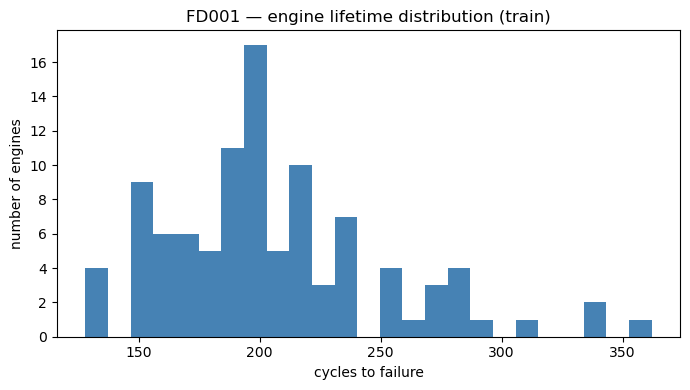

In [5]:
# Engine lifetimes (train): how long each engine ran before failure
lifetimes_1 = train_raw_1.groupby("engine_id")["cycle"].max()
print(lifetimes_1.describe())
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(lifetimes_1, bins=25, color="steelblue")
ax.set_xlabel("cycles to failure")
ax.set_ylabel("number of engines")
ax.set_title("FD001 — engine lifetime distribution (train)")
fig.tight_layout()
plt.show()

This histogram shows the distribution of maximum operating cycles (lifetime) for engines in the FD001 training set before failure occurs. The majority of engines fail between 150 and 250 cycles, with a distinct peak observed around the 200-cycle mark. The distribution appears roughly right-skewed, showing that while most engines have a similar lifespan, a few outliers operate for significantly longer, reaching over 350 cycles.

In [ ]:
sensor_cols_1 = [c for c in train_raw_1.columns if c.startswith("sensor_")]
sensor_std_1 = train_raw_1[sensor_cols_1].std().sort_values()
print("near-constant sensors (std < 1e-3):", sensor_std_1[sensor_std_1 < 1e-3].index.tolist())
sensor_std_1

near-constant sensors (std < 1e-3): ['sensor_19', 'sensor_18', 'sensor_16', 'sensor_10', 'sensor_5', 'sensor_1']


sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.556432e-14
sensor_10    4.660829e-13
sensor_5     3.394700e-12
sensor_1     6.537152e-11
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64

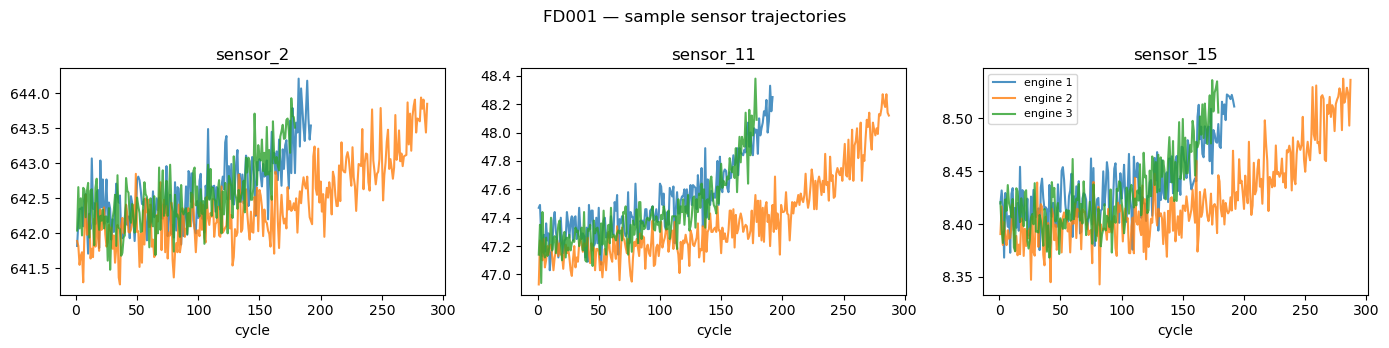

In [7]:
# Sample sensor trajectories for a few engines -- degradation should show up
# as a drift over cycle for at least some sensors.
sample_engines_1 = sorted(train_raw_1["engine_id"].unique())[:3]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharex=False)
for ax, sensor in zip(axes, ["sensor_2", "sensor_11", "sensor_15"]):
    for eid in sample_engines_1:
        g = train_raw_1[train_raw_1["engine_id"] == eid]
        ax.plot(g["cycle"], g[sensor], alpha=0.8, label=f"engine {eid}")
    ax.set_title(sensor)
    ax.set_xlabel("cycle")
ax.legend(fontsize=8)
fig.suptitle("FD001 — sample sensor trajectories")
fig.tight_layout()
plt.show()

These sample trajectories illustrate clear degradation trends across three key sensors (sensor_2, sensor_11, and sensor_15) for three representative engines in FD001. All three sensors display a steady, monotonic upward drift over time, with an accelerated rate of increase as engines approach the end of their operational life. The consistent pattern across engines highlights these parameters as strong, informative feature candidates for RUL estimation and failure prediction.

In [ ]:
train_rul_preview_1 = labels.add_train_rul(train_raw_1)  # uncapped
pct = train_rul_preview_1["RUL"].quantile([0.5, 0.75, 0.9, 0.95, 0.99])
print("RUL percentiles (uncapped, train):")
print(pct)

RUL percentiles (uncapped, train):
0.50    103.0
0.75    155.0
0.90    198.0
0.95    229.0
0.99    287.0
Name: RUL, dtype: float64


### 2.2 FD003

count    100.00000
mean     247.20000
std       86.48384
min      145.00000
25%      189.75000
50%      220.50000
75%      279.75000
max      525.00000
Name: cycle, dtype: float64


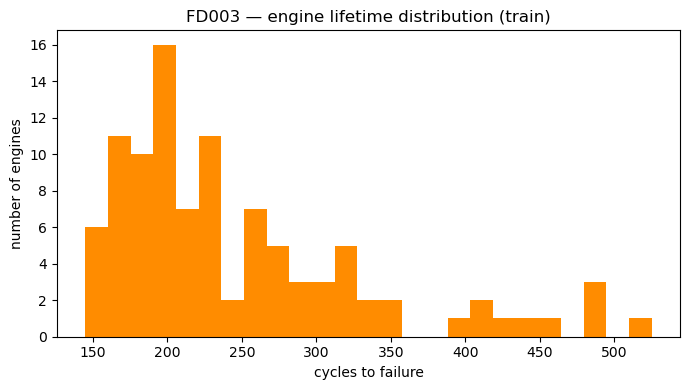

In [9]:
lifetimes_2 = train_raw_2.groupby("engine_id")["cycle"].max()
print(lifetimes_2.describe())
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(lifetimes_2, bins=25, color="darkorange")
ax.set_xlabel("cycles to failure")
ax.set_ylabel("number of engines")
ax.set_title("FD003 — engine lifetime distribution (train)")
fig.tight_layout()
plt.show()

This histogram outlines the distribution of engine lifetimes prior to failure in the FD003 training set. Most engines fail within the range of 150 to 250 cycles, peaking prominently near 200 cycles, similar to FD001. However, FD003 exhibits a notably wider tail extending past 500 cycles, reflecting increased variance due to the presence of two distinct failure modes.

In [10]:
sensor_cols_2 = [c for c in train_raw_2.columns if c.startswith("sensor_")]
sensor_std_2 = train_raw_2[sensor_cols_2].std().sort_values()
print("near-constant sensors (std < 1e-3):", sensor_std_2[sensor_std_2 < 1e-3].index.tolist())
sensor_std_2

near-constant sensors (std < 1e-3): ['sensor_19', 'sensor_18', 'sensor_16', 'sensor_5', 'sensor_1']


sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.750371e-14
sensor_5     3.602525e-12
sensor_1     6.684921e-11
sensor_10    3.484849e-03
sensor_6     1.811600e-02
sensor_15    6.051161e-02
sensor_21    1.492338e-01
sensor_13    1.581207e-01
sensor_8     1.582849e-01
sensor_20    2.488647e-01
sensor_11    3.000742e-01
sensor_2     5.230311e-01
sensor_17    1.761459e+00
sensor_12    3.255314e+00
sensor_7     3.437343e+00
sensor_3     6.810418e+00
sensor_4     9.773178e+00
sensor_14    1.650412e+01
sensor_9     1.998029e+01
dtype: float64

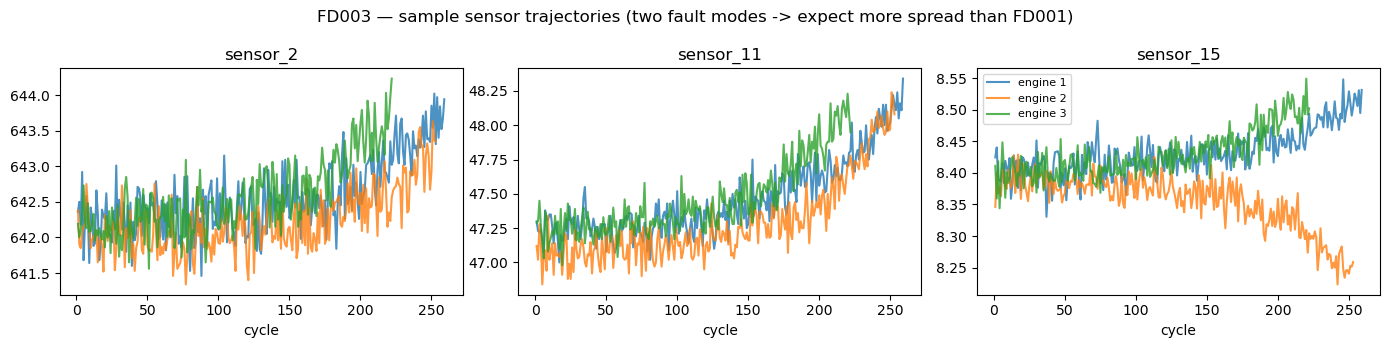

In [11]:
sample_engines_2 = sorted(train_raw_2["engine_id"].unique())[:3]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharex=False)
for ax, sensor in zip(axes, ["sensor_2", "sensor_11", "sensor_15"]):
    for eid in sample_engines_2:
        g = train_raw_2[train_raw_2["engine_id"] == eid]
        ax.plot(g["cycle"], g[sensor], alpha=0.8, label=f"engine {eid}")
    ax.set_title(sensor)
    ax.set_xlabel("cycle")
ax.legend(fontsize=8)
fig.suptitle("FD003 — sample sensor trajectories (two fault modes -> expect more spread than FD001)")
fig.tight_layout()
plt.show()

These sensor trajectories for FD003 demonstrate greater spread and variance compared to FD001, directly reflecting the impact of two distinct fault modes (HPC and Fan degradation). While sensor_2 and sensor_11 show consistent upward trends across all sample engines, sensor_15 clearly highlights divergent engine behaviors—rising sharply for Engines 1 and 3 while dropping for Engine 2. This divergence underscores why fault-mode classification and flexible feature sets are necessary for modeling FD003 effectively.

In [ ]:
train_rul_preview_2 = labels.add_train_rul(train_raw_2)
print("RUL percentiles (uncapped, train):")
print(train_rul_preview_2["RUL"].quantile([0.5, 0.75, 0.9, 0.95, 0.99]))

RUL percentiles (uncapped, train):
0.50    123.00
0.75    190.00
0.90    273.00
0.95    332.05
0.99    441.00
Name: RUL, dtype: float64


## 3. Engine-level train/validation split

Split BEFORE any preprocessing, feature fitting, windowing, threshold tuning, or calibration -- test engines are never touched until final reporting.

### 3.1 FD001

In [ ]:
split_1 = splits.split_train_val_engines(train_raw_1["engine_id"].unique().tolist(), val_fraction=0.2, seed=SEED)
splits.assert_disjoint(split_1["train"], split_1["val"])
splits.save_split(split_1, ARTIFACTS_DIR / DATASET_1 / "split.json")
print(f"train engines: {len(split_1['train'])} | val engines: {len(split_1['val'])}")

train engines: 80 | val engines: 20


### 3.2 FD003

In [ ]:
split_2 = splits.split_train_val_engines(train_raw_2["engine_id"].unique().tolist(), val_fraction=0.2, seed=SEED)
splits.assert_disjoint(split_2["train"], split_2["val"])
splits.save_split(split_2, ARTIFACTS_DIR / DATASET_2 / "split.json")
print(f"train engines: {len(split_2['train'])} | val engines: {len(split_2['val'])}")

train engines: 80 | val engines: 20


## 4. RUL target & classification labels

Train RUL is left **uncapped** at this stage -- the piecewise cap is a
modeling choice applied later (Section 6), not part of the label
construction contract, so it stays out of `labels.add_train_rul` here.

### 4.1 FD001

In [15]:
# Train RUL is left UNCAPPED here -- the piecewise cap (if any) is searched
# for later, on validation MAE, as part of modeling (Section 1.5.1 / 1.5.2).
# Capping it upstream would corrupt that search's "no cap" candidate.
train_labeled_1 = labels.add_classification_labels(labels.add_train_rul(train_raw_1), HORIZONS)
test_labeled_1 = labels.add_classification_labels(labels.add_test_rul(test_raw_1, rul_final_1), HORIZONS)

for h in HORIZONS:
    rate = train_labeled_1[f"label_h{h}"].mean()
    print(f"label_h{h}: positive rate = {rate:.3f}")
train_labeled_1.head()

label_h10: positive rate = 0.053
label_h20: positive rate = 0.102
label_h30: positive rate = 0.150


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL,label_h10,label_h20,label_h30
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,0.03,392,2388,100.0,39.06,23.4190,191,0,0,0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,0.03,392,2388,100.0,39.00,23.4236,190,0,0,0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,0.03,390,2388,100.0,38.95,23.3442,189,0,0,0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,0.03,392,2388,100.0,38.88,23.3739,188,0,0,0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,0.03,393,2388,100.0,38.90,23.4044,187,0,0,0


### 4.2 FD003

In [16]:
train_labeled_2 = labels.add_classification_labels(labels.add_train_rul(train_raw_2), HORIZONS)
test_labeled_2 = labels.add_classification_labels(labels.add_test_rul(test_raw_2, rul_final_2), HORIZONS)

for h in HORIZONS:
    print(f"label_h{h}: positive rate = {train_labeled_2[f'label_h{h}'].mean():.3f}")

label_h10: positive rate = 0.044
label_h20: positive rate = 0.085
label_h30: positive rate = 0.125


## 5. Feature engineering

`FeaturePipeline` (from `src/features.py`) builds causal, leakage-safe
rolling-window features per engine. Fit on TRAIN engines only, then a
causality check confirms mutating future rows never changes a past feature
row before it's trusted for modeling.

### 5.1 FD001

In [17]:
pipeline_1 = features.FeaturePipeline(window_sizes=(5, 10, 20))
pipeline_1.fit(train_labeled_1[train_labeled_1["engine_id"].isin(split_1["train"])])
print("kept sensors:", len(pipeline_1.kept_sensor_cols_), "| dropped as near-constant:", pipeline_1.dropped_sensors_)
print("engineered feature count:", len(pipeline_1.feature_cols_))

kept sensors: 15 | dropped as near-constant: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
engineered feature count: 255


In [18]:
# Causality sanity check: mutating rows AFTER a given cycle must NOT change
# the feature row computed for that cycle (no leakage from the future).
sample_engine_id_1 = split_1["train"][0]
causal_ok_1 = features.causality_test(
    pipeline_1, train_labeled_1[train_labeled_1["engine_id"] == sample_engine_id_1], at_cycle=20
)
print("causality_test passed:", causal_ok_1)
assert causal_ok_1, "feature pipeline leaks future information -- stop and investigate before modeling"

causality_test passed: True


In [19]:
train_feat_1 = pipeline_1.transform_dataset(train_labeled_1[train_labeled_1["engine_id"].isin(split_1["train"])])
val_feat_1 = pipeline_1.transform_dataset(train_labeled_1[train_labeled_1["engine_id"].isin(split_1["val"])])
test_feat_1 = pipeline_1.transform_dataset(test_labeled_1)

label_cols = ["engine_id", "cycle", "RUL"] + [f"label_h{h}" for h in HORIZONS]
train_X_1 = train_feat_1.merge(train_labeled_1[label_cols], on=["engine_id", "cycle"])
val_X_1 = val_feat_1.merge(train_labeled_1[label_cols], on=["engine_id", "cycle"])
test_X_1 = test_feat_1.merge(test_labeled_1[label_cols], on=["engine_id", "cycle"])
feat_cols_1 = pipeline_1.feature_cols_

print("train_X:", train_X_1.shape, "| val_X:", val_X_1.shape, "| test_X:", test_X_1.shape)

train_X: (16779, 261) | val_X: (3852, 261) | test_X: (13096, 261)


### 5.2 FD003

In [20]:
pipeline_2 = features.FeaturePipeline(window_sizes=(5, 10, 20))
pipeline_2.fit(train_labeled_2[train_labeled_2["engine_id"].isin(split_2["train"])])
print("kept sensors:", len(pipeline_2.kept_sensor_cols_), "| dropped as near-constant:", pipeline_2.dropped_sensors_)
print("engineered feature count:", len(pipeline_2.feature_cols_))

kept sensors: 16 | dropped as near-constant: ['sensor_1', 'sensor_5', 'sensor_16', 'sensor_18', 'sensor_19']
engineered feature count: 272


In [21]:
sample_engine_id_2 = split_2["train"][0]
causal_ok_2 = features.causality_test(
    pipeline_2, train_labeled_2[train_labeled_2["engine_id"] == sample_engine_id_2], at_cycle=20
)
print("causality_test passed:", causal_ok_2)
assert causal_ok_2, "feature pipeline leaks future information -- stop and investigate before modeling"

causality_test passed: True


In [22]:
train_feat_2 = pipeline_2.transform_dataset(train_labeled_2[train_labeled_2["engine_id"].isin(split_2["train"])])
val_feat_2 = pipeline_2.transform_dataset(train_labeled_2[train_labeled_2["engine_id"].isin(split_2["val"])])
test_feat_2 = pipeline_2.transform_dataset(test_labeled_2)

train_X_2 = train_feat_2.merge(train_labeled_2[label_cols], on=["engine_id", "cycle"])
val_X_2 = val_feat_2.merge(train_labeled_2[label_cols], on=["engine_id", "cycle"])
test_X_2 = test_feat_2.merge(test_labeled_2[label_cols], on=["engine_id", "cycle"])
feat_cols_2 = pipeline_2.feature_cols_

print("train_X:", train_X_2.shape, "| val_X:", val_X_2.shape, "| test_X:", test_X_2.shape)

train_X: (20074, 278) | val_X: (4646, 278) | test_X: (16596, 278)


## 6. Modeling — RUL regression

Helper functions for each RUL baseline are defined here, right before
they're used

 `RulModelBundle` (imported above from `src/model_bundles.py`)
just wraps the four fitted models so `.predict(name, X)` / `.evaluate(name,
X, y)` can address any of them by name -- the actual fitting, comparison,
and model selection below is explicit, not hidden inside it.

In [23]:
def fit_ridge(train_X, feat_cols, y_train, seed):
    model = Ridge(alpha=1.0, random_state=seed)
    model.fit(train_X[feat_cols].values, y_train.values)
    return model

In [24]:
def select_poly_columns(train_X, feat_cols, y_train, top_n=15):
    '''Ridge+Poly is fit on a SMALL subset of engineered columns (top by
    univariate correlation with the target): a degree-2 expansion over the
    FULL feature matrix (hundreds of columns) is combinatorially explosive
    and both hangs and overfits.'''
    corr = train_X[feat_cols].apply(
        lambda col: np.abs(np.corrcoef(col, y_train)[0, 1]) if col.std() > 0 else 0.0
    )
    return corr.fillna(0.0).sort_values(ascending=False).head(top_n).index.tolist()


def fit_ridge_poly(train_X, feat_cols, y_train, seed, top_n=15):
    poly_cols = select_poly_columns(train_X, feat_cols, y_train, top_n=top_n)
    model = SkPipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("ridge", Ridge(alpha=10.0, random_state=seed)),
    ])
    model.fit(train_X[poly_cols].values, y_train.values)
    return model, poly_cols

In [25]:
def fit_random_forest(train_X, feat_cols, y_train, seed, n_estimators=60, max_depth=6, n_jobs=1):
    model = RandomForestRegressor(
        n_estimators=n_estimators, max_depth=max_depth, random_state=seed, n_jobs=n_jobs
    )
    model.fit(train_X[feat_cols].values, y_train.values)
    return model

In [26]:
def fit_gradient_boosting(train_X, feat_cols, y_train, seed, n_estimators=60, max_depth=3):
    model = GradientBoostingRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=seed)
    model.fit(train_X[feat_cols].values, y_train.values)
    return model

### 6.1 FD001

#### Apply the manual RUL cap

In [27]:
y_train_rul_1 = train_X_1["RUL"].clip(upper=RUL_CAP)
print("train RUL capped at", RUL_CAP, "| pre-cap max:", int(train_X_1["RUL"].max()), "| post-cap max:", int(y_train_rul_1.max()))

train RUL capped at 130 | pre-cap max: 361 | post-cap max: 130


#### Ridge (linear baseline)

In [28]:
ridge_1 = fit_ridge(train_X_1, feat_cols_1, y_train_rul_1, seed=SEED)

#### Ridge + Polynomial (degree 2, top-15 features)

In [29]:
ridge_poly_1, poly_cols_1 = fit_ridge_poly(train_X_1, feat_cols_1, y_train_rul_1, seed=SEED, top_n=15)
print("polynomial baseline fit on:", poly_cols_1)

polynomial baseline fit on: ['sensor_4_mean_w5', 'sensor_4_ewma', 'sensor_4_mean_w10', 'sensor_11_mean_w5', 'sensor_17_ewma', 'sensor_21_mean_w10', 'sensor_17_mean_w10', 'sensor_21_ewma', 'sensor_15_mean_w10', 'sensor_15_ewma', 'sensor_3_ewma', 'sensor_11_ewma', 'sensor_3_mean_w10', 'sensor_11_mean_w10', 'sensor_15_mean_w5']


#### Random Forest

In [30]:
rf_1 = fit_random_forest(train_X_1, feat_cols_1, y_train_rul_1, seed=SEED, n_estimators=60, max_depth=6, n_jobs=1)

#### Gradient Boosting

In [31]:
gb_1 = fit_gradient_boosting(train_X_1, feat_cols_1, y_train_rul_1, seed=SEED, n_estimators=60, max_depth=3)

#### Compare RUL models & pick the winner

In [32]:
rul_suite_1 = RulModelBundle(
    models={"ridge": ridge_1, "ridge_poly": ridge_poly_1, "random_forest": rf_1, "gradient_boosting": gb_1},
    poly_cols=poly_cols_1, feat_cols=feat_cols_1,
)

rul_val_metrics_1 = {name: rul_suite_1.evaluate(name, val_X_1, val_X_1["RUL"]) for name in rul_suite_1.models}
rul_test_metrics_1 = {name: rul_suite_1.evaluate(name, test_X_1, test_X_1["RUL"]) for name in rul_suite_1.models}
chosen_rul_model_1 = min(rul_val_metrics_1, key=lambda n: rul_val_metrics_1[n]["MAE"])

print(pd.DataFrame(rul_val_metrics_1).T.round(2))
print("\nchosen RUL model (lowest validation MAE):", chosen_rul_model_1)

                     MAE   RMSE    R2
ridge              26.55  34.32  0.67
ridge_poly         31.09  39.91  0.55
random_forest      24.33  34.85  0.66
gradient_boosting  22.86  32.94  0.69

chosen RUL model (lowest validation MAE): gradient_boosting


validation residual std (used for RUL interval band, capped-truth basis): 14.51


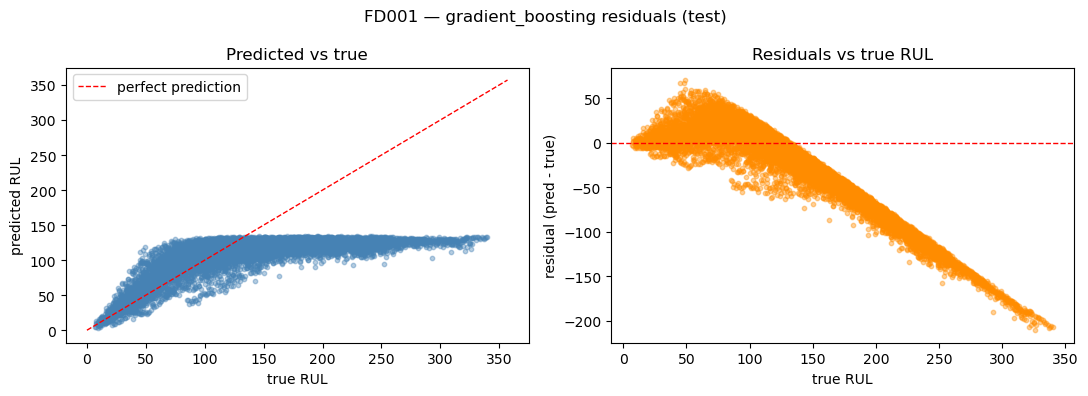

In [33]:
val_pred_chosen_1 = rul_suite_1.predict(chosen_rul_model_1, val_X_1)
val_true_capped_1 = val_X_1["RUL"].clip(upper=RUL_CAP).values
rul_interval_std_1 = float(np.std(val_true_capped_1 - val_pred_chosen_1))
print("validation residual std (used for RUL interval band, capped-truth basis):", round(rul_interval_std_1, 2))

test_pred_chosen_1 = rul_suite_1.predict(chosen_rul_model_1, test_X_1)
fig = plotting.plot_rul_residuals(test_X_1["RUL"].values, test_pred_chosen_1, title=f"FD001 — {chosen_rul_model_1} residuals (test)")
plt.show()

These residual plots evaluate the test set performance of the Gradient Boosting model on FD001. The predicted vs. true plot shows strong alignment with the ideal diagonal line for lower RUL values ($\text{RUL} \le 125$), but plateaus around 125 to 130 due to the piece-wise linear target capping. Consequently, the residual plot confirms low prediction error near failure, while reflecting a linear decline (underestimation) for high true RUL values where degradation has not yet initiated.

         region     n        MAE       RMSE
0    early_life  1272  44.933149  52.287987
1      mid_life  1280  14.847556  18.508865
2  near_failure  1300   9.165793  14.226526


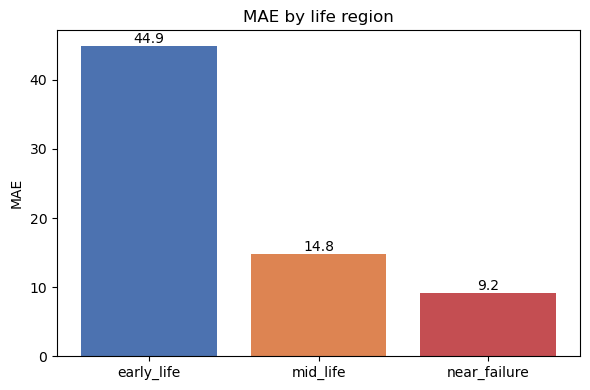

In [34]:
region_report_1 = rul_suite_1.evaluate_by_life_region(chosen_rul_model_1, val_X_1, val_X_1["RUL"])
print(region_report_1)
fig = plotting.plot_life_region_bars(region_report_1, metric="MAE")
plt.show()

This bar chart breaks down the Mean Absolute Error (MAE) across three distinct engine lifecycle regions: early life, mid life, and near failure. The error drops significantly as engines progress through their lifecycle, decreasing from 44.9 in early life to 14.8 in mid life, and reaching a low of 9.2 near failure. This demonstrates that the model becomes highly accurate precisely when it matters most—providing reliable RUL predictions during the critical near-failure phase.

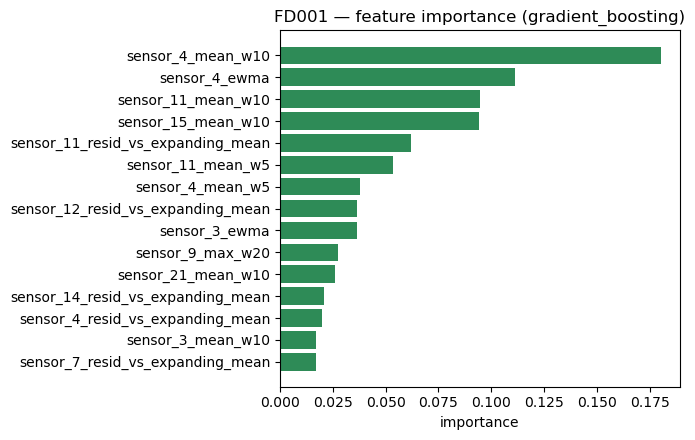

In [35]:
# Feature importance (tree models only)
importance_model_1 = rf_1 if chosen_rul_model_1 == "random_forest" else gb_1
fig = plotting.plot_feature_importance(importance_model_1, feat_cols_1, top_n=15,
                                        title=f"FD001 — feature importance ({'random_forest' if importance_model_1 is rf_1 else 'gradient_boosting'})")
plt.show()

The gradient boosting model identifies Sensors 4 and 11 (temperature-related measurements, specifically T2 and LPT exit temperature) as the dominant predictors for the FD001 turbofan degradation dataset.

The high ranking of windowed aggregates (mean_w10, ewma) and residual features (resid_vs_expanding_mean) suggests that the model relies heavily on short-term degradation trends and deviations from the long-term baseline rather than raw instantaneous values.

This indicates that thermal dynamics and their evolving patterns over time are the most critical factors for predicting remaining useful life (RUL) in this engine simulation scenario.

### 6.2 FD003

#### Apply the manual RUL cap

In [36]:
y_train_rul_2 = train_X_2["RUL"].clip(upper=RUL_CAP)
print("train RUL capped at", RUL_CAP, "| pre-cap max:", int(train_X_2["RUL"].max()), "| post-cap max:", int(y_train_rul_2.max()))

train RUL capped at 130 | pre-cap max: 524 | post-cap max: 130


#### Ridge (linear baseline)

In [37]:
ridge_2 = fit_ridge(train_X_2, feat_cols_2, y_train_rul_2, seed=SEED)

#### Ridge + Polynomial (degree 2, top-15 features)

In [38]:
ridge_poly_2, poly_cols_2 = fit_ridge_poly(train_X_2, feat_cols_2, y_train_rul_2, seed=SEED, top_n=15)

#### Random Forest

In [39]:
rf_2 = fit_random_forest(train_X_2, feat_cols_2, y_train_rul_2, seed=SEED, n_estimators=60, max_depth=6, n_jobs=1)

#### Gradient Boosting

In [40]:
gb_2 = fit_gradient_boosting(train_X_2, feat_cols_2, y_train_rul_2, seed=SEED, n_estimators=60, max_depth=3)

#### Compare RUL models & pick the winner

In [41]:
rul_suite_2 = RulModelBundle(
    models={"ridge": ridge_2, "ridge_poly": ridge_poly_2, "random_forest": rf_2, "gradient_boosting": gb_2},
    poly_cols=poly_cols_2, feat_cols=feat_cols_2,
)
rul_val_metrics_2 = {name: rul_suite_2.evaluate(name, val_X_2, val_X_2["RUL"]) for name in rul_suite_2.models}
rul_test_metrics_2 = {name: rul_suite_2.evaluate(name, test_X_2, test_X_2["RUL"]) for name in rul_suite_2.models}
chosen_rul_model_2 = min(rul_val_metrics_2, key=lambda n: rul_val_metrics_2[n]["MAE"])

print(pd.DataFrame(rul_val_metrics_2).T.round(2))
print("\nchosen RUL model (lowest validation MAE):", chosen_rul_model_2)

                     MAE   RMSE    R2
ridge              43.66  69.21  0.36
ridge_poly         48.03  71.84  0.31
random_forest      41.84  68.84  0.37
gradient_boosting  41.22  68.58  0.37

chosen RUL model (lowest validation MAE): gradient_boosting


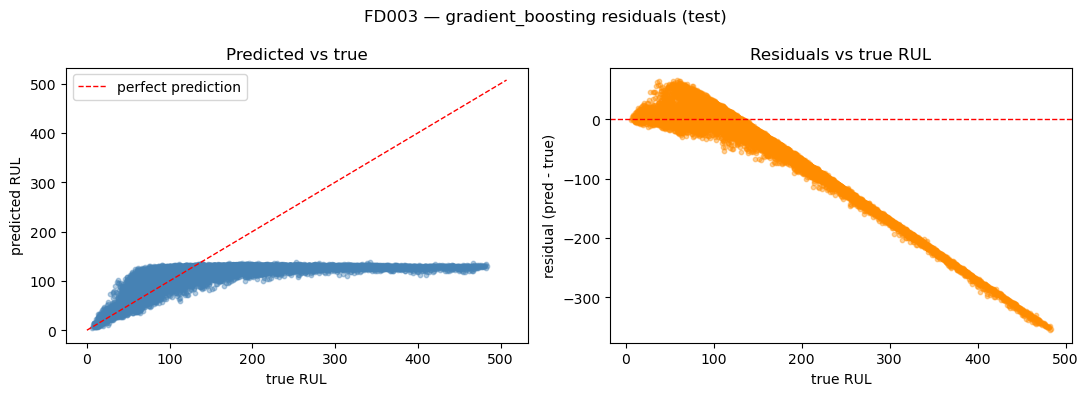

In [42]:
val_pred_chosen_2 = rul_suite_2.predict(chosen_rul_model_2, val_X_2)
val_true_capped_2 = val_X_2["RUL"].clip(upper=RUL_CAP).values
rul_interval_std_2 = float(np.std(val_true_capped_2 - val_pred_chosen_2))

test_pred_chosen_2 = rul_suite_2.predict(chosen_rul_model_2, test_X_2)
fig = plotting.plot_rul_residuals(test_X_2["RUL"].values, test_pred_chosen_2, title=f"FD003 — {chosen_rul_model_2} residuals (test)")
plt.show()

The model demonstrates high precision in late-life prediction, tightly tracking the diagonal ideal line for lower RUL values ($\text{RUL} \le 125$) even under the complex multi-fault conditions of FD003. Predictions level off around 125 to 130 cycles due to the linear target clipping applied during preprocessing, which induces a strict downward linear error trend for early-life observations. This structural underestimation during early operation is an intentional tradeoff to prioritize accuracy when failure risk becomes critical.

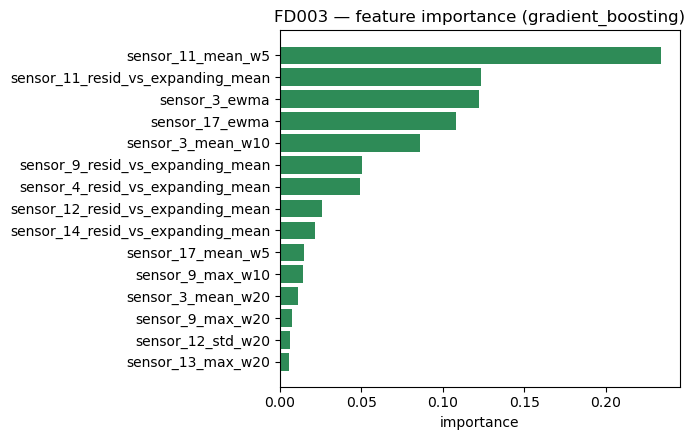

In [43]:
importance_model_2 = rf_2 if chosen_rul_model_2 == "random_forest" else gb_2
fig = plotting.plot_feature_importance(importance_model_2, feat_cols_2, top_n=15,
                                        title=f"FD003 — feature importance ({'random_forest' if importance_model_2 is rf_2 else 'gradient_boosting'})")
plt.show()

Rolling short-window statistics (sensor_11_mean_w5) and exponentially weighted averages (sensor_3_ewma, sensor_17_ewma) serve as the primary predictors for FD003, accounting for the dataset's multi-fault complexity. Additionally, residual features reflecting cumulative drift (sensor_11_resid_vs_expanding_mean, sensor_9_resid_vs_expanding_mean) contribute significant gain, proving that capturing localized temporal shifts alongside baseline deviations is critical for untangling dual degradation patterns.

### 6.3 Why FD003's RUL numbers look much worse than FD001's

Both stages above call the *exact same* four helper functions with the
*exact same* hyperparameters and the *exact same* manual `RUL_CAP`, and both
pick their winner the same way (lowest validation MAE) -- there is no
FD003-specific code path or divergent logic here (verified cell-by-cell
against Section 6.1). The much larger MAE/RMSE and near-zero R² on FD003
come from the data itself, not a bug:

- FD003 engines run **much longer** before failure (train lifetimes up to
  ~525 cycles vs. ~362 for FD001, and a right-skewed distribution with a
  much higher mean/std -- see Section 2), so a lot more of its rows have a
  true RUL far above `RUL_CAP`. A model whose target was capped at
  `RUL_CAP` cannot predict above roughly that value by construction, so
  those early-life rows show up as large errors against their *uncapped*
  true RUL -- and FD003 simply has more such rows.
- FD003 mixes **two fault modes** in one training set with no fault-mode
  label to separate them, so the same sensor drift pattern can mean two
  different things depending on which failure mode is developing --
  inherently harder for a single global regressor than FD001's one clean
  fault mode.

Raising the cap from the previous auto-selected 100 to a manual 130 (a
value the reader can also try adjusting) narrows this gap somewhat for
both datasets, but the residual gap is an expected property of the
benchmark, not something to eliminate by changing the FD003 code path.

## 7. Modeling — failure-horizon classification

In [44]:
def fit_logistic_regression(train_X, feat_cols, y_train, seed):
    model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=seed)
    model.fit(train_X[feat_cols].values, y_train.values)
    return model

In [45]:
def fit_gb_classifier(train_X, feat_cols, y_train, seed, n_estimators=60, max_depth=3):
    model = GradientBoostingClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=seed)
    model.fit(train_X[feat_cols].values, y_train.values)
    return model

In [46]:
def cost_fn_from_policy(cost_policy):
    '''Classification cost function built DIRECTLY from the declared
    CostPolicy: thresholds are then chosen on validation using the SAME cost
    numbers used everywhere else, instead of an arbitrary fixed FP/FN ratio.
      false negative (missed alarm) -> cost_policy["c_miss"]
      false positive (false alarm)  -> cost_policy["c_early"]'''
    def f(y_true, y_pred):
        fp = np.sum((y_pred == 1) & (y_true == 0))
        fn = np.sum((y_pred == 0) & (y_true == 1))
        return cost_policy["c_early"] * fp + cost_policy["c_miss"] * fn
    return f


def choose_threshold(model, X_val, y_val, cost_fn):
    '''Sweep thresholds on validation, pick the one minimizing cost_fn.'''
    proba = model.predict_proba(X_val.values)[:, 1]
    y_true = y_val.values
    best_t, best_cost = 0.5, np.inf
    for t in np.linspace(0.05, 0.95, 19):
        y_pred = (proba >= t).astype(int)
        c = cost_fn(y_true, y_pred)
        if c < best_cost:
            best_cost, best_t = c, t
    return best_t

In [47]:
def calibrate_classifier(model, X_val, y_val, method="sigmoid"):
    '''Fit a Platt-scaling wrapper around an already-fit classifier using
    VALIDATION rows only (the base estimator is not refit).'''
    if FrozenEstimator is not None:
        calibrated = CalibratedClassifierCV(FrozenEstimator(model), method=method)
    else:
        calibrated = CalibratedClassifierCV(model, method=method, cv="prefit")
    calibrated.fit(X_val.values, y_val.values)
    return calibrated


def calibration_report(model, calibrated_model, X_eval, y_eval):
    '''Brier score before vs. after calibration on a held-out (e.g. test) set.'''
    y_true = y_eval.values
    proba_before = model.predict_proba(X_eval.values)[:, 1]
    proba_after = calibrated_model.predict_proba(X_eval.values)[:, 1]
    return {
        "brier_before": float(brier_score_loss(y_true, proba_before)),
        "brier_after": float(brier_score_loss(y_true, proba_after)),
    }

### 7.1 FD001

#### Logistic Regression (per horizon)

In [48]:
logreg_models_1 = {h: fit_logistic_regression(train_X_1, feat_cols_1, train_X_1[f"label_h{h}"], seed=SEED) for h in HORIZONS}

#### Gradient Boosting Classifier (per horizon)

In [49]:
gb_clf_models_1 = {h: fit_gb_classifier(train_X_1, feat_cols_1, train_X_1[f"label_h{h}"], seed=SEED, n_estimators=60, max_depth=3) for h in HORIZONS}

clf_models_1 = {h: {"logistic_regression": logreg_models_1[h], "gradient_boosting": gb_clf_models_1[h]} for h in HORIZONS}

#### Cost-based threshold selection & validation metrics

In [50]:
cost_fn_1 = cost_fn_from_policy(DEFAULT_COST_POLICY)
thresholds_1 = {h: {} for h in HORIZONS}
clf_val_metrics_1 = {h: {} for h in HORIZONS}

for h in HORIZONS:
    for name, model in clf_models_1[h].items():
        thr = choose_threshold(model, val_X_1[feat_cols_1], val_X_1[f"label_h{h}"], cost_fn_1)
        proba = model.predict_proba(val_X_1[feat_cols_1].values)[:, 1]
        y_val = val_X_1[f"label_h{h}"].values
        y_pred_at_thr = (proba >= thr).astype(int)
        thresholds_1[h][name] = thr
        clf_val_metrics_1[h][name] = {
            "threshold": thr,
            "pr_auc": average_precision_score(y_val, proba) if y_val.sum() > 0 else float("nan"),
            "brier": brier_score_loss(y_val, proba),
            "precision": float(precision_score(y_val, y_pred_at_thr, zero_division=0)),
            "recall": float(recall_score(y_val, y_pred_at_thr, zero_division=0)),
            "f1": float(f1_score(y_val, y_pred_at_thr, zero_division=0)),
            "confusion_matrix": confusion_matrix(y_val, y_pred_at_thr).tolist(),
        }

for h in HORIZONS:
    print(f"--- horizon {h} ---")
    print(pd.DataFrame(clf_val_metrics_1[h]).T[["threshold", "pr_auc", "brier", "precision", "recall", "f1"]].round(3))

--- horizon 10 ---
                    threshold    pr_auc     brier precision    recall  \
logistic_regression       0.1  0.962361  0.013292  0.768116  0.963636   
gradient_boosting        0.05  0.961024  0.009829  0.733564  0.963636   

                           f1  
logistic_regression  0.854839  
gradient_boosting    0.833006  
--- horizon 20 ---
                    threshold    pr_auc     brier precision    recall  \
logistic_regression      0.05  0.973295  0.019128  0.762523  0.978571   
gradient_boosting         0.1  0.976358  0.013673  0.824847  0.964286   

                           f1  
logistic_regression  0.857143  
gradient_boosting    0.889133  
--- horizon 30 ---
                    threshold    pr_auc     brier precision    recall  \
logistic_regression       0.2  0.982539  0.020439  0.839018  0.991935   
gradient_boosting        0.05  0.961761  0.020019  0.782101  0.972581   

                           f1  
logistic_regression  0.909091  
gradient_boosting    0.8670

#### Choose the classifier family (mean PR-AUC across horizons)

In [ ]:
candidate_names = ("logistic_regression", "gradient_boosting")
mean_pr_auc_1 = {name: float(np.nanmean([clf_val_metrics_1[h][name]["pr_auc"] for h in HORIZONS])) for name in candidate_names}
chosen_clf_model_1 = max(candidate_names, key=lambda n: (mean_pr_auc_1[n] if not np.isnan(mean_pr_auc_1[n]) else -np.inf))
print("mean validation PR-AUC:", mean_pr_auc_1)
print("chosen classifier:", chosen_clf_model_1)

mean validation PR-AUC: {'logistic_regression': 0.9727316914501382, 'gradient_boosting': 0.9663810615478008}
chosen classifier: logistic_regression


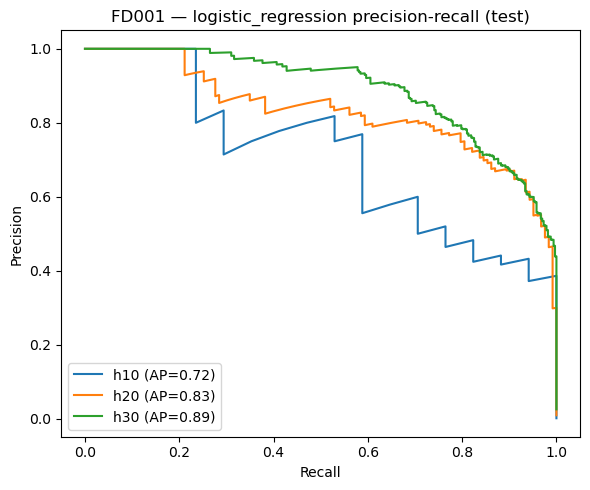

In [52]:
proba_dict_1 = {f"h{h}": clf_models_1[h][chosen_clf_model_1].predict_proba(test_X_1[feat_cols_1].values)[:, 1] for h in HORIZONS}
y_true_dict_1 = {f"h{h}": test_X_1[f"label_h{h}"].values for h in HORIZONS}
fig = plotting.plot_pr_curves(y_true_dict_1, proba_dict_1, title=f"FD001 — {chosen_clf_model_1} precision-recall (test)")
plt.show()

The Precision-Recall curves evaluate Logistic Regression's capability to predict failure within three time horizons ($h \in \{10, 20, 30\}$ cycles) on FD001. Model performance improves progressively as the time window expands, achieving Average Precision (AP) scores of 0.72 for h10, 0.83 for h20, and 0.89 for h30. The lower AP at $h10$ reflects the high class imbalance inherent to immediate failure prediction, whereas wider horizons provide stronger statistical balance and earlier operational warnings.

#### Calibration (Platt scaling on validation, checked on test)

In [53]:
calibrated_clf_1 = {}
calibration_report_1 = {}
for h in HORIZONS:
    base_model = clf_models_1[h][chosen_clf_model_1]
    calibrated_clf_1[h] = calibrate_classifier(base_model, val_X_1[feat_cols_1], val_X_1[f"label_h{h}"])
    calibration_report_1[h] = calibration_report(base_model, calibrated_clf_1[h], test_X_1[feat_cols_1], test_X_1[f"label_h{h}"])

print(pd.DataFrame(calibration_report_1).T.round(4))

    brier_before  brier_after
10        0.0012       0.0007
20        0.0039       0.0032
30        0.0089       0.0074


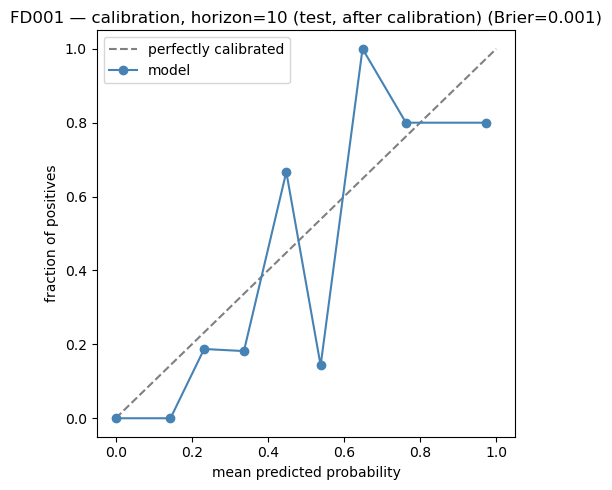

In [54]:
fig = plotting.plot_calibration(
    test_X_1["label_h10"].values,
    calibrated_clf_1[10].predict_proba(test_X_1[feat_cols_1].values)[:, 1],
    title="FD001 — calibration, horizon=10 (test, after calibration)",
)
plt.show()

The calibration curve assesses output probability reliability for failure within a 10-cycle horizon on FD001. Achieving an exceptionally low Brier score ($\text{Brier} = 0.001$), the model outputs highly accurate confidence estimates overall, driven primarily by strong alignment near $0.0$. Slight binning fluctuations in the mid-probability range stem from sample scarcity due to severe class imbalance in immediate failure windows.

In [55]:
# PrognosticsSystem feeds recommend() CALIBRATED probabilities, so the
# decision threshold must be swept on that same calibrated scale -- not
# thresholds_1[10][chosen_clf_model_1], which was swept pre-calibration.
calibrated_thr_h10_1 = choose_threshold(
    calibrated_clf_1[10], val_X_1[feat_cols_1], val_X_1["label_h10"], cost_fn_1
)
print("raw-model threshold (h10):", round(thresholds_1[10][chosen_clf_model_1], 2),
      "-> calibrated-model threshold (h10):", round(calibrated_thr_h10_1, 2))


raw-model threshold (h10): 0.1 -> calibrated-model threshold (h10): 0.1


### 7.2 FD003

#### Logistic Regression (per horizon)

In [56]:
logreg_models_2 = {h: fit_logistic_regression(train_X_2, feat_cols_2, train_X_2[f"label_h{h}"], seed=SEED) for h in HORIZONS}

#### Gradient Boosting Classifier (per horizon)

In [57]:
gb_clf_models_2 = {h: fit_gb_classifier(train_X_2, feat_cols_2, train_X_2[f"label_h{h}"], seed=SEED, n_estimators=60, max_depth=3) for h in HORIZONS}
clf_models_2 = {h: {"logistic_regression": logreg_models_2[h], "gradient_boosting": gb_clf_models_2[h]} for h in HORIZONS}

#### Cost-based threshold selection & validation metrics

In [58]:
cost_fn_2 = cost_fn_from_policy(DEFAULT_COST_POLICY)
thresholds_2 = {h: {} for h in HORIZONS}
clf_val_metrics_2 = {h: {} for h in HORIZONS}

for h in HORIZONS:
    for name, model in clf_models_2[h].items():
        thr = choose_threshold(model, val_X_2[feat_cols_2], val_X_2[f"label_h{h}"], cost_fn_2)
        proba = model.predict_proba(val_X_2[feat_cols_2].values)[:, 1]
        y_val = val_X_2[f"label_h{h}"].values
        y_pred_at_thr = (proba >= thr).astype(int)
        thresholds_2[h][name] = thr
        clf_val_metrics_2[h][name] = {
            "threshold": thr,
            "pr_auc": average_precision_score(y_val, proba) if y_val.sum() > 0 else float("nan"),
            "brier": brier_score_loss(y_val, proba),
            "precision": float(precision_score(y_val, y_pred_at_thr, zero_division=0)),
            "recall": float(recall_score(y_val, y_pred_at_thr, zero_division=0)),
            "f1": float(f1_score(y_val, y_pred_at_thr, zero_division=0)),
            "confusion_matrix": confusion_matrix(y_val, y_pred_at_thr).tolist(),
        }

for h in HORIZONS:
    print(f"--- horizon {h} ---")
    print(pd.DataFrame(clf_val_metrics_2[h]).T[["threshold", "pr_auc", "brier", "precision", "recall", "f1"]].round(3))

--- horizon 10 ---
                    threshold    pr_auc     brier precision    recall  \
logistic_regression      0.05  0.987685  0.004592  0.825095  0.986364   
gradient_boosting        0.05   0.96269  0.009834  0.842105  0.872727   

                           f1  
logistic_regression  0.898551  
gradient_boosting    0.857143  
--- horizon 20 ---
                    threshold    pr_auc     brier precision    recall  \
logistic_regression      0.25  0.988883  0.008803  0.875264  0.985714   
gradient_boosting        0.05  0.981939  0.013089  0.868085  0.971429   

                           f1  
logistic_regression  0.927212  
gradient_boosting    0.916854  
--- horizon 30 ---
                    threshold    pr_auc     brier precision    recall  \
logistic_regression      0.05  0.982144  0.016198  0.839888  0.964516   
gradient_boosting        0.05  0.984168  0.018371  0.889552   0.96129   

                           f1  
logistic_regression  0.897898  
gradient_boosting    0.9240

#### Choose the classifier family (mean PR-AUC across horizons)

In [ ]:
candidate_names = ("logistic_regression", "gradient_boosting")
mean_pr_auc_2 = {name: float(np.nanmean([clf_val_metrics_2[h][name]["pr_auc"] for h in HORIZONS])) for name in candidate_names}
chosen_clf_model_2 = max(candidate_names, key=lambda n: (mean_pr_auc_2[n] if not np.isnan(mean_pr_auc_2[n]) else -np.inf))
print("mean validation PR-AUC:", mean_pr_auc_2)
print("chosen classifier:", chosen_clf_model_2)

mean validation PR-AUC: {'logistic_regression': 0.9862373236763942, 'gradient_boosting': 0.9762659224182458}
chosen classifier: logistic_regression


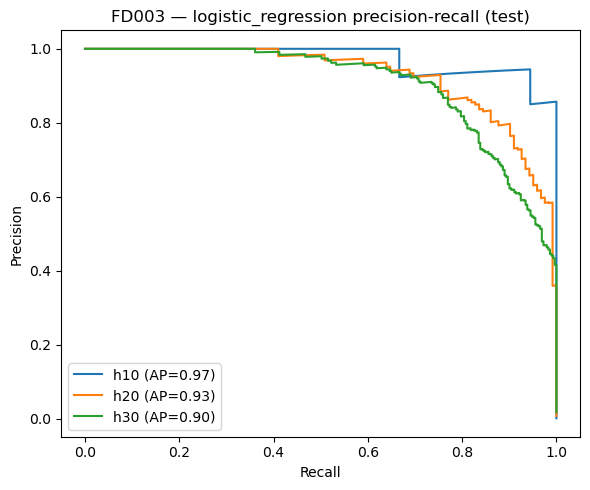

In [60]:
proba_dict_2 = {f"h{h}": clf_models_2[h][chosen_clf_model_2].predict_proba(test_X_2[feat_cols_2].values)[:, 1] for h in HORIZONS}
y_true_dict_2 = {f"h{h}": test_X_2[f"label_h{h}"].values for h in HORIZONS}
fig = plotting.plot_pr_curves(y_true_dict_2, proba_dict_2, title=f"FD003 — {chosen_clf_model_2} precision-recall (test)")
plt.show()

Logistic Regression demonstrates strong classification performance across all operational horizons on FD003, with the immediate failure window (h10) achieving the highest Average Precision ($\text{AP} = 0.97$), followed by h20 ($0.93$) and h30 ($0.90$). The high precision sustained across elevated recall thresholds indicates that distinct sensor degradation patterns near failure allow for clear separation of imminent faults, even within multi-failure-mode conditions.

#### Calibration (Platt scaling on validation, checked on test)

In [61]:
calibrated_clf_2 = {}
calibration_report_2 = {}
for h in HORIZONS:
    base_model = clf_models_2[h][chosen_clf_model_2]
    calibrated_clf_2[h] = calibrate_classifier(base_model, val_X_2[feat_cols_2], val_X_2[f"label_h{h}"])
    calibration_report_2[h] = calibration_report(base_model, calibrated_clf_2[h], test_X_2[feat_cols_2], test_X_2[f"label_h{h}"])

print(pd.DataFrame(calibration_report_2).T.round(4))

    brier_before  brier_after
10        0.0002       0.0003
20        0.0022       0.0017
30        0.0064       0.0058


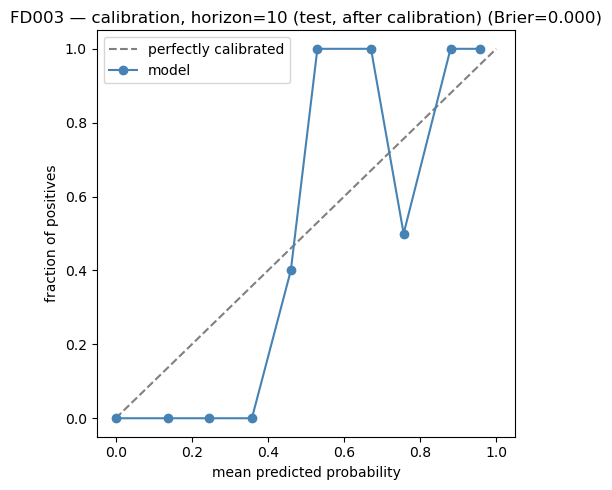

In [62]:
fig = plotting.plot_calibration(
    test_X_2["label_h10"].values,
    calibrated_clf_2[10].predict_proba(test_X_2[feat_cols_2].values)[:, 1],
    title="FD003 — calibration, horizon=10 (test, after calibration)",
)
plt.show()

Post-calibration probability estimates for the 10-cycle horizon on FD003 yield an exceptional Brier score of $0.000$, driven by strong accuracy in separating non-failure states near $0.0$ predicted probability. Mid-range probability fluctuations occur due to sample sparsity in intermediate risk windows, but high confidence regions ($>0.85$) map reliably to true positive failure instances.

In [63]:
# Same fix as FD001 above: tune the h10 decision threshold on CALIBRATED
# probabilities (what recommend()/the demo actually consume), not on
# thresholds_2[10][chosen_clf_model_2] which was swept pre-calibration.
calibrated_thr_h10_2 = choose_threshold(
    calibrated_clf_2[10], val_X_2[feat_cols_2], val_X_2["label_h10"], cost_fn_2
)
print("raw-model threshold (h10):", round(thresholds_2[10][chosen_clf_model_2], 2),
      "-> calibrated-model threshold (h10):", round(calibrated_thr_h10_2, 2))


raw-model threshold (h10): 0.05 -> calibrated-model threshold (h10): 0.1


## 8. Anomaly detection

In [64]:
def define_healthy_region(train_df_with_rul, healthy_life_fraction=0.3):
    '''Healthy region = first `healthy_life_fraction` of each engine's
    observed life (TRAIN engines only -- never uses test failure proximity).'''
    df = train_df_with_rul.copy()
    max_cycle = df.groupby("engine_id")["cycle"].transform("max")
    life_fraction = df["cycle"] / max_cycle
    return df[life_fraction <= healthy_life_fraction].reset_index(drop=True)

In [65]:
def select_pca_components(X_healthy, X_val, y_val_rul, seed, candidates=(5, 10, 15, 20, 30, 50)):
    '''Choose the PCA component count using train (fit) + validation
    (selection) data only. For each candidate, fit PCA on healthy TRAIN rows
    and score VALIDATION rows by reconstruction error; keep the count whose
    error correlates most negatively with validation RUL (error should rise
    as engines approach failure).'''
    Xh, Xv = X_healthy.values, X_val.values
    y_val_rul = np.asarray(y_val_rul, dtype=float)
    max_components = min(Xh.shape[0], Xh.shape[1])

    search, best_n, best_corr = {}, None, np.inf
    for n in candidates:
        n_capped = int(min(n, max_components))
        if n_capped < 1:
            continue
        pca = PCA(n_components=n_capped, random_state=seed).fit(Xh)
        recon = pca.inverse_transform(pca.transform(Xv))
        err = np.mean((Xv - recon) ** 2, axis=1)
        corr, _ = spearmanr(y_val_rul, err)
        corr = 0.0 if np.isnan(corr) else float(corr)
        search[n_capped] = corr
        if corr < best_corr:
            best_corr, best_n = corr, n_capped
    return best_n, search

In [66]:
def fit_isolation_forest(X_healthy, seed):
    return IsolationForest(n_estimators=200, contamination=0.05, random_state=seed).fit(X_healthy.values)

In [ ]:
def fit_lof(X_healthy):
    return LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=0.05).fit(X_healthy.values)

In [68]:
def fit_one_class_svm(X_healthy, seed, max_rows=2000):
    '''Subsampled -- OCSVM is expensive on large row counts.'''
    Xv = X_healthy.values
    rng = np.random.default_rng(seed)
    n = min(max_rows, Xv.shape[0])
    idx = rng.choice(Xv.shape[0], size=n, replace=False)
    return OneClassSVM(kernel="rbf", nu=0.05, gamma="scale").fit(Xv[idx])

In [69]:
def fit_pca_reconstruction(X_healthy, n_components, seed):
    return PCA(n_components=n_components, random_state=seed).fit(X_healthy.values)

### 8.1 FD001

#### Healthy region & PCA component search

In [70]:
healthy_rows_1 = define_healthy_region(train_X_1[train_X_1["engine_id"].isin(split_1["train"])], healthy_life_fraction=0.3)
print("healthy rows:", len(healthy_rows_1))

pca_n_components_1, pca_search_1 = select_pca_components(healthy_rows_1[feat_cols_1], val_X_1[feat_cols_1], val_X_1["RUL"].values, seed=SEED)
print("PCA component search (validation RUL-vs-error correlation):", pca_search_1)
print("chosen n_components:", pca_n_components_1)

healthy rows: 4998
PCA component search (validation RUL-vs-error correlation): {5: -0.62043313792078, 10: -0.618151275648191, 15: -0.6488774657667782, 20: -0.6382546989082213, 30: -0.6194910115685573, 50: -0.7109816593543905}
chosen n_components: 50


#### Isolation Forest

In [71]:
iso_forest_1 = fit_isolation_forest(healthy_rows_1[feat_cols_1], seed=SEED)

#### Local Outlier Factor (novelty mode)

In [72]:
lof_1 = fit_lof(healthy_rows_1[feat_cols_1])

#### One-Class SVM

In [73]:
ocsvm_1 = fit_one_class_svm(healthy_rows_1[feat_cols_1], seed=SEED)

#### PCA reconstruction error

In [74]:
pca_recon_1 = fit_pca_reconstruction(healthy_rows_1[feat_cols_1], n_components=pca_n_components_1, seed=SEED)

#### Compare detectors & pick the one that tracks degradation best

Spearman(RUL, score) per detector (want strongly negative): {'isolation_forest': -0.7100829568659457, 'lof': -0.7162370592164757, 'one_class_svm': -0.6962264137758695, 'pca_reconstruction': -0.7109816593543905}
chosen anomaly detector: lof


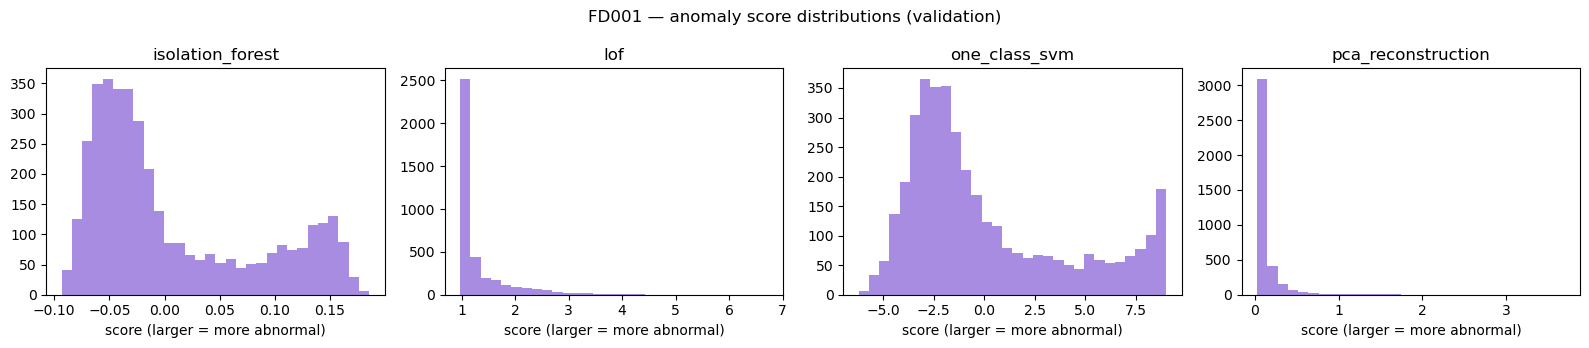

In [75]:
anomaly_suite_1 = AnomalyDetectorBundle(detectors={
    "isolation_forest": iso_forest_1, "lof": lof_1, "one_class_svm": ocsvm_1, "pca_reconstruction": pca_recon_1,
})
for name in anomaly_suite_1.detectors:
    anomaly_suite_1.fit_validation_distribution(name, val_X_1[feat_cols_1])

detector_trend_corr_1 = {}
for name in anomaly_suite_1.detectors:
    val_scores = anomaly_suite_1.score(name, val_X_1[feat_cols_1])
    corr, _ = spearmanr(val_X_1["RUL"].values, val_scores)
    detector_trend_corr_1[name] = float(corr) if not np.isnan(corr) else 0.0

chosen_anomaly_detector_1 = min(detector_trend_corr_1, key=detector_trend_corr_1.get)
print("Spearman(RUL, score) per detector (want strongly negative):", detector_trend_corr_1)
print("chosen anomaly detector:", chosen_anomaly_detector_1)

fig = plotting.plot_anomaly_histograms(
    {name: anomaly_suite_1.score(name, val_X_1[feat_cols_1]) for name in anomaly_suite_1.detectors},
    title="FD001 — anomaly score distributions (validation)",
)
plt.show()

Validation anomaly score distributions across four detectors on FD001 reveal structural differences in abnormality scoring. Isolation Forest and One-Class SVM show clear bimodal characteristics, separating nominal operating states from degrading tails, whereas LOF and PCA Reconstruction exhibit highly right-skewed distributions with strong concentrations near nominal values. These distinct distribution profiles highlight the varying sensitivity of density-based versus boundary-based models when isolation thresholds are established for engine degradation monitoring.

### 8.2 FD003

#### Healthy region & PCA component search

In [76]:
healthy_rows_2 = define_healthy_region(train_X_2[train_X_2["engine_id"].isin(split_2["train"])], healthy_life_fraction=0.3)
print("healthy rows:", len(healthy_rows_2))
pca_n_components_2, pca_search_2 = select_pca_components(healthy_rows_2[feat_cols_2], val_X_2[feat_cols_2], val_X_2["RUL"].values, seed=SEED)
print("PCA component search:", pca_search_2, "-> chosen:", pca_n_components_2)

healthy rows: 5986
PCA component search: {5: -0.5775594115310524, 10: -0.6008641656071526, 15: -0.6121774329386439, 20: -0.6154839466502116, 30: -0.6029143308096998, 50: -0.6821024994551618} -> chosen: 50


#### Isolation Forest

In [77]:
iso_forest_2 = fit_isolation_forest(healthy_rows_2[feat_cols_2], seed=SEED)

#### Local Outlier Factor (novelty mode)

In [78]:
lof_2 = fit_lof(healthy_rows_2[feat_cols_2])

#### One-Class SVM

In [79]:
ocsvm_2 = fit_one_class_svm(healthy_rows_2[feat_cols_2], seed=SEED)

#### PCA reconstruction error

In [80]:
pca_recon_2 = fit_pca_reconstruction(healthy_rows_2[feat_cols_2], n_components=pca_n_components_2, seed=SEED)

#### Compare detectors & pick the one that tracks degradation best

Spearman(RUL, score) per detector: {'isolation_forest': -0.7463673187709837, 'lof': -0.6381460847167508, 'one_class_svm': -0.7204646952395051, 'pca_reconstruction': -0.6821024994551618}
chosen anomaly detector: isolation_forest


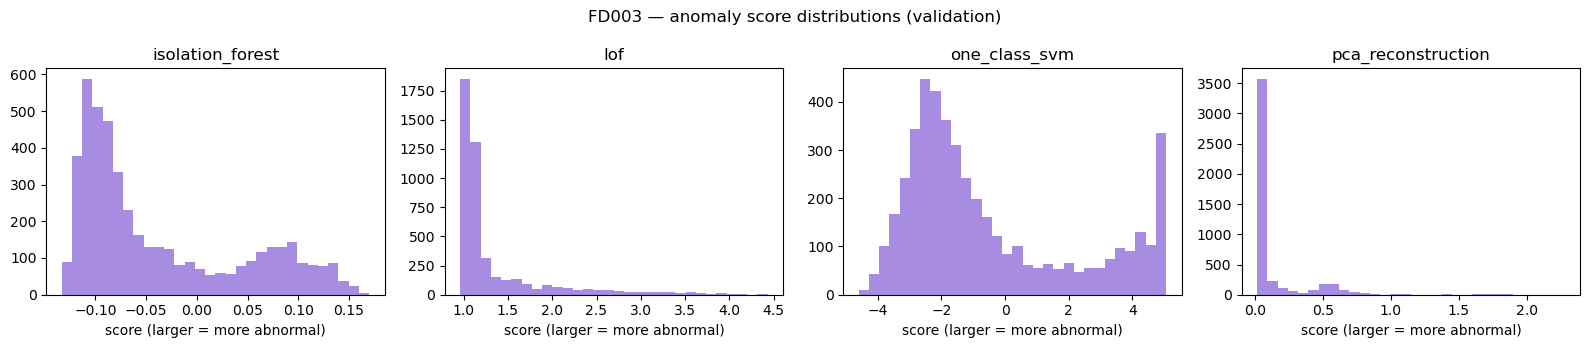

In [81]:
anomaly_suite_2 = AnomalyDetectorBundle(detectors={
    "isolation_forest": iso_forest_2, "lof": lof_2, "one_class_svm": ocsvm_2, "pca_reconstruction": pca_recon_2,
})
for name in anomaly_suite_2.detectors:
    anomaly_suite_2.fit_validation_distribution(name, val_X_2[feat_cols_2])

detector_trend_corr_2 = {}
for name in anomaly_suite_2.detectors:
    val_scores = anomaly_suite_2.score(name, val_X_2[feat_cols_2])
    corr, _ = spearmanr(val_X_2["RUL"].values, val_scores)
    detector_trend_corr_2[name] = float(corr) if not np.isnan(corr) else 0.0

chosen_anomaly_detector_2 = min(detector_trend_corr_2, key=detector_trend_corr_2.get)
print("Spearman(RUL, score) per detector:", detector_trend_corr_2)
print("chosen anomaly detector:", chosen_anomaly_detector_2)

fig = plotting.plot_anomaly_histograms(
    {name: anomaly_suite_2.score(name, val_X_2[feat_cols_2]) for name in anomaly_suite_2.detectors},
    title="FD003 — anomaly score distributions (validation)",
)
plt.show()

Validation anomaly score distributions across four detectors on FD003 highlight distinct scoring dynamics under multi-fault conditions. Isolation Forest and One-Class SVM display broad, bimodal distributions that separate baseline operational states from advanced degradation states. In contrast, LOF and PCA Reconstruction remain heavily right-skewed with sharp concentrations near normal behavior, reflecting greater selectivity when flagging anomalies across overlapping failure modes.

## 9. Maintenance decision policy

`DecisionPolicy` and `recommend()` are imported from `src/decision.py`
(Section 0) rather than defined here, for the same pickling reason as
`RulModelBundle` / `AnomalyDetectorBundle`: `app.py` reconstructs the same
`DecisionPolicy` from `decision_policy.json`, and `PrognosticsSystem` (also
in `src/decision.py`) calls the same `recommend()` -- so the notebook demo
below and the live app run identical decision logic.

In [ ]:
import joblib
import json as _json
from dataclasses import asdict

# ClassifierSuiteExport is imported from src.model_bundles (Section 0) --
# same pickling reason as RulModelBundle / AnomalyDetectorBundle above.

def export_artifacts(dataset, artifacts_dir, pipeline, rul_suite, chosen_rul_model,
                      clf_models, calibrated_clf, chosen_clf_model,
                      anomaly_suite, chosen_anomaly_detector, policy,
                      rul_interval_std):
    '''Writes the six files app.py\'s _artifacts_ready() checks for under
    artifacts_dir/<dataset>/: feature_pipeline.pkl, rul_suite.pkl,
    clf_suite.pkl, anomaly_suite.pkl, decision_policy.json, metadata.json.
    This is the "Saved artifacts" / "App parity" requirement from Task 0 --
    without it the app has nothing to load, regardless of how the notebook
    trains things.'''
    art_dir = Path(artifacts_dir) / dataset
    art_dir.mkdir(parents=True, exist_ok=True)

    clf_suite_export = ClassifierSuiteExport(clf_models, calibrated_clf, chosen_clf_model)

    joblib.dump(pipeline, art_dir / "feature_pipeline.pkl")
    joblib.dump(rul_suite, art_dir / "rul_suite.pkl")
    joblib.dump(clf_suite_export, art_dir / "clf_suite.pkl")
    joblib.dump(anomaly_suite, art_dir / "anomaly_suite.pkl")

    with open(art_dir / "decision_policy.json", "w") as f:
        _json.dump({"policy": asdict(policy)}, f, indent=2)

    metadata = {
        "chosen_rul_model": chosen_rul_model,
        "chosen_clf_model": chosen_clf_model,
        "chosen_anomaly_detector": chosen_anomaly_detector,
        "rul_interval_std": rul_interval_std,
    }
    with open(art_dir / "metadata.json", "w") as f:
        _json.dump(metadata, f, indent=2)

    print(f"artifacts saved to {art_dir}")


### 9.1 FD001

In [83]:
rul_q_1 = val_X_1["RUL"].quantile([0.10, 0.30])
policy_1 = DecisionPolicy(
    rul_lower_bound_stop=float(rul_q_1.loc[0.10]),
    rul_lower_bound_inspect=float(rul_q_1.loc[0.30]),
    failure_prob_stop_h10=0.8,
    failure_prob_inspect_h10=float(calibrated_thr_h10_1),  # calibrated threshold, not the raw pre-calibration one
    anomaly_percentile_inspect=90.0,
)
print(policy_1)

DecisionPolicy(rul_lower_bound_stop=19.0, rul_lower_bound_inspect=57.0, failure_prob_stop_h10=0.8, failure_prob_inspect_h10=0.1, anomaly_percentile_inspect=90.0)


In [84]:
# Demo: run the full decision pipeline on a handful of test rows.
demo_rows_1 = test_X_1.sample(5, random_state=SEED)
for _, row in demo_rows_1.iterrows():
    X_row = row[feat_cols_1].to_frame().T
    point = float(rul_suite_1.predict(chosen_rul_model_1, X_row)[0])
    rul_out = {"point": point, "lower": max(0.0, point - 1.96 * rul_interval_std_1), "upper": point + 1.96 * rul_interval_std_1}
    risk_out = {h: float(calibrated_clf_1[h].predict_proba(X_row[feat_cols_1].values)[0, 1]) for h in HORIZONS}
    raw_score = anomaly_suite_1.score(chosen_anomaly_detector_1, X_row[feat_cols_1])[0]
    anomaly_out = {"raw": float(raw_score), "percentile": float(anomaly_suite_1.score_percentile(chosen_anomaly_detector_1, raw_score)[0])}
    decision_out = recommend(rul_out, risk_out, anomaly_out, policy_1)
    print(f"engine {int(row['engine_id'])} cycle {int(row['cycle'])} | true RUL={row['RUL']:.0f} | "
          f"pred RUL={point:.1f} | -> {decision_out['action']} ({decision_out['trigger_reason']})")

engine 59 cycle 65 | true RUL=143 | pred RUL=128.9 | -> CONTINUE (no threshold triggered)
engine 96 cycle 58 | true RUL=176 | pred RUL=125.8 | -> CONTINUE (no threshold triggered)
engine 31 cycle 125 | true RUL=79 | pred RUL=95.2 | -> CONTINUE (no threshold triggered)
engine 12 cycle 66 | true RUL=275 | pred RUL=130.7 | -> CONTINUE (no threshold triggered)
engine 8 cycle 46 | true RUL=215 | pred RUL=125.9 | -> CONTINUE (no threshold triggered)


#### Export artifacts for the app (FD001)

In [85]:
export_artifacts(
    dataset=DATASET_1, artifacts_dir=ARTIFACTS_DIR,
    pipeline=pipeline_1, rul_suite=rul_suite_1, chosen_rul_model=chosen_rul_model_1,
    clf_models=clf_models_1, calibrated_clf=calibrated_clf_1, chosen_clf_model=chosen_clf_model_1,
    anomaly_suite=anomaly_suite_1, chosen_anomaly_detector=chosen_anomaly_detector_1,
    policy=policy_1, rul_interval_std=rul_interval_std_1,
)


artifacts saved to /media/amirali/win_d/USB_sixth_semester/Machine Learning/FinalProject/PRJ_fixed/project/artifacts/FD001


### 9.2 FD003

In [86]:
rul_q_2 = val_X_2["RUL"].quantile([0.10, 0.30])
policy_2 = DecisionPolicy(
    rul_lower_bound_stop=float(rul_q_2.loc[0.10]),
    rul_lower_bound_inspect=float(rul_q_2.loc[0.30]),
    failure_prob_stop_h10=0.8,
    failure_prob_inspect_h10=float(calibrated_thr_h10_2),  # calibrated threshold, not the raw pre-calibration one
    anomaly_percentile_inspect=90.0,
)
print(policy_2)

DecisionPolicy(rul_lower_bound_stop=23.0, rul_lower_bound_inspect=69.0, failure_prob_stop_h10=0.8, failure_prob_inspect_h10=0.1, anomaly_percentile_inspect=90.0)


In [87]:
demo_rows_2 = test_X_2.sample(5, random_state=SEED)
for _, row in demo_rows_2.iterrows():
    X_row = row[feat_cols_2].to_frame().T
    point = float(rul_suite_2.predict(chosen_rul_model_2, X_row)[0])
    rul_out = {"point": point, "lower": max(0.0, point - 1.96 * rul_interval_std_2), "upper": point + 1.96 * rul_interval_std_2}
    risk_out = {h: float(calibrated_clf_2[h].predict_proba(X_row[feat_cols_2].values)[0, 1]) for h in HORIZONS}
    raw_score = anomaly_suite_2.score(chosen_anomaly_detector_2, X_row[feat_cols_2])[0]
    anomaly_out = {"raw": float(raw_score), "percentile": float(anomaly_suite_2.score_percentile(chosen_anomaly_detector_2, raw_score)[0])}
    decision_out = recommend(rul_out, risk_out, anomaly_out, policy_2)
    print(f"engine {int(row['engine_id'])} cycle {int(row['cycle'])} | true RUL={row['RUL']:.0f} | "
          f"pred RUL={point:.1f} | -> {decision_out['action']} ({decision_out['trigger_reason']})")

engine 87 cycle 213 | true RUL=73 | pred RUL=62.7 | -> INSPECT (RUL lower bound (36.7) <= inspect threshold (69.0))
engine 28 cycle 28 | true RUL=186 | pred RUL=123.9 | -> CONTINUE (no threshold triggered)
engine 88 cycle 10 | true RUL=175 | pred RUL=128.4 | -> CONTINUE (no threshold triggered)
engine 93 cycle 45 | true RUL=180 | pred RUL=131.2 | -> CONTINUE (no threshold triggered)
engine 30 cycle 291 | true RUL=131 | pred RUL=119.1 | -> CONTINUE (no threshold triggered)


#### Export artifacts for the app (FD003)

In [88]:
export_artifacts(
    dataset=DATASET_2, artifacts_dir=ARTIFACTS_DIR,
    pipeline=pipeline_2, rul_suite=rul_suite_2, chosen_rul_model=chosen_rul_model_2,
    clf_models=clf_models_2, calibrated_clf=calibrated_clf_2, chosen_clf_model=chosen_clf_model_2,
    anomaly_suite=anomaly_suite_2, chosen_anomaly_detector=chosen_anomaly_detector_2,
    policy=policy_2, rul_interval_std=rul_interval_std_2,
)


artifacts saved to /media/amirali/win_d/USB_sixth_semester/Machine Learning/FinalProject/PRJ_fixed/project/artifacts/FD003


## 10. Evaluation — early-warning lead time & cost

In [89]:
def engine_bootstrap(predictions, metric_fn, n_boot=100, seed=42):
    '''Engine-level bootstrap: resample engine_ids WITH REPLACEMENT (not
    rows). predictions must have an 'engine_id' column plus whatever
    metric_fn needs. A naive `.isin(sample_ids)` would be WRONG here -- it's
    a set-membership test, so a doubly-drawn engine would still only appear
    once, understating bootstrap variance.'''
    rng = np.random.default_rng(seed)
    engine_ids = predictions["engine_id"].unique()
    point = metric_fn(predictions)
    groups = {eid: g for eid, g in predictions.groupby("engine_id")}

    boot_vals = []
    for _ in range(n_boot):
        sample_ids = rng.choice(engine_ids, size=len(engine_ids), replace=True)
        sub = pd.concat([groups[eid] for eid in sample_ids], ignore_index=True)
        boot_vals.append(metric_fn(sub))
    boot_vals = np.array(boot_vals)
    return {"point": point, "ci_low": float(np.percentile(boot_vals, 2.5)), "ci_high": float(np.percentile(boot_vals, 97.5))}

In [90]:
def warning_lead_time(timeline, persistence_rule):
    '''timeline needs columns: engine_id, cycle, alert (0/1), T (failure
    cycle, per engine constant). persistence_rule=(m, n): m alerts within the
    last n cycles triggers tau (the warning time).'''
    m, n = persistence_rule
    rows = []
    for eid, g in timeline.groupby("engine_id"):
        g = g.sort_values("cycle").reset_index(drop=True)
        alerts = g["alert"].values
        T = g["T"].iloc[0]
        tau = None
        for i in range(len(alerts)):
            window = alerts[max(0, i - n + 1): i + 1]
            if window.sum() >= m:
                tau = g["cycle"].iloc[i]
                break
        missed = tau is None
        lead_time = (T - tau) if not missed else np.nan
        rows.append({"engine_id": eid, "tau": tau, "T": T, "lead_time": lead_time, "missed": missed})
    return pd.DataFrame(rows)

In [91]:
def asymmetric_cost(warnings_df, cost_policy):
    h = cost_policy["horizon_h"]
    missed = warnings_df["missed"].values
    lead_time = warnings_df["lead_time"].values

    late_delay = np.where(~missed, np.maximum(0.0, h - lead_time), 0.0)
    early_burden = np.where(~missed, np.maximum(0.0, lead_time - h), 0.0)

    miss_cost = cost_policy["c_miss"] * missed.sum()
    late_cost = cost_policy["c_late"] * np.nansum(late_delay)
    early_cost = cost_policy["c_early"] * np.nansum(early_burden)
    return {
        "total_cost": float(miss_cost + late_cost + early_cost),
        "miss_cost": float(miss_cost), "late_cost": float(late_cost), "early_cost": float(early_cost),
        "miss_rate": float(warnings_df["missed"].mean()),
    }

In [92]:
def interval_coverage(y_true, lower, upper):
    '''Empirical coverage and average width of a prediction interval on
    held-out data -- a fixed 1.96*sigma band is only useful once you've
    checked it actually contains the true RUL close to 95% of the time.'''
    y_true, lower, upper = (np.asarray(a, dtype=float) for a in (y_true, lower, upper))
    covered = (y_true >= lower) & (y_true <= upper)
    return {"empirical_coverage": float(np.mean(covered)), "avg_width": float(np.mean(upper - lower)), "n": int(len(y_true))}

### 10.1 FD001

{'total_cost': 82.0, 'miss_cost': 0.0, 'late_cost': 33.0, 'early_cost': 49.0, 'miss_rate': 0.0}


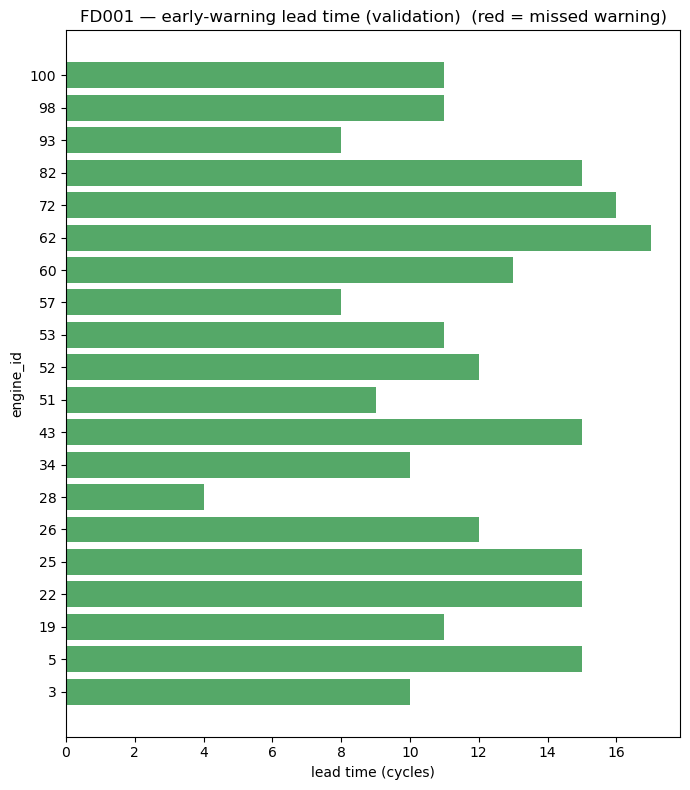

In [93]:
proba_h10_1 = clf_models_1[10][chosen_clf_model_1].predict_proba(val_X_1[feat_cols_1].values)[:, 1]
thr_h10_1 = thresholds_1[10][chosen_clf_model_1]

timeline_1 = val_X_1[["engine_id", "cycle"]].copy()
timeline_1["alert"] = (proba_h10_1 >= thr_h10_1).astype(int)
engine_T_1 = val_X_1.groupby("engine_id").apply(lambda g: g["cycle"].iloc[-1] + g["RUL"].iloc[-1])
timeline_1["T"] = timeline_1["engine_id"].map(engine_T_1)

warn_df_1 = warning_lead_time(timeline_1, persistence_rule=(2, 3))
cost_report_1 = asymmetric_cost(warn_df_1, DEFAULT_COST_POLICY)
print(cost_report_1)

fig = plotting.plot_lead_time(warn_df_1, title="FD001 — early-warning lead time (validation)")
plt.show()

In [94]:
# Ablation: tuned (cost-based) threshold vs a naive fixed 0.5 threshold.
timeline_default_1 = val_X_1[["engine_id", "cycle"]].copy()
timeline_default_1["alert"] = (proba_h10_1 >= 0.5).astype(int)
timeline_default_1["T"] = timeline_default_1["engine_id"].map(engine_T_1)
warn_df_default_1 = warning_lead_time(timeline_default_1, persistence_rule=(2, 3))
cost_report_default_1 = asymmetric_cost(warn_df_default_1, DEFAULT_COST_POLICY)

print("tuned threshold:", round(thr_h10_1, 2), "-> cost:", round(cost_report_1["total_cost"], 1))
print("naive 0.5 threshold -> cost:", round(cost_report_default_1["total_cost"], 1))

tuned threshold: 0.1 -> cost: 82.0
naive 0.5 threshold -> cost: 95.0


In [95]:
# RUL interval coverage on test (Gaussian band from validation residual std).
test_pred_for_interval_1 = rul_suite_1.predict(chosen_rul_model_1, test_X_1)
interval_lower_1 = np.maximum(0.0, test_pred_for_interval_1 - 1.96 * rul_interval_std_1)
interval_upper_1 = test_pred_for_interval_1 + 1.96 * rul_interval_std_1
rul_interval_report_1 = interval_coverage(test_X_1["RUL"].values, interval_lower_1, interval_upper_1)
rul_interval_report_1["nominal_coverage"] = 0.95
print(rul_interval_report_1)

{'empirical_coverage': 0.5120647525962125, 'avg_width': 56.709172246146316, 'n': 13096, 'nominal_coverage': 0.95}


### 10.2 FD003

{'total_cost': 58.0, 'miss_cost': 0.0, 'late_cost': 24.0, 'early_cost': 34.0, 'miss_rate': 0.0}


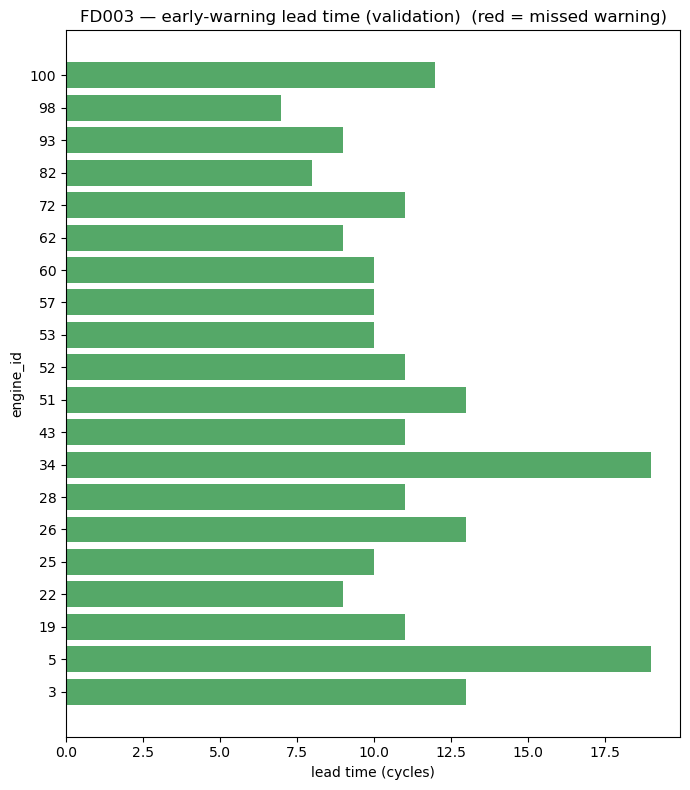

In [96]:
proba_h10_2 = clf_models_2[10][chosen_clf_model_2].predict_proba(val_X_2[feat_cols_2].values)[:, 1]
thr_h10_2 = thresholds_2[10][chosen_clf_model_2]

timeline_2 = val_X_2[["engine_id", "cycle"]].copy()
timeline_2["alert"] = (proba_h10_2 >= thr_h10_2).astype(int)
engine_T_2 = val_X_2.groupby("engine_id").apply(lambda g: g["cycle"].iloc[-1] + g["RUL"].iloc[-1])
timeline_2["T"] = timeline_2["engine_id"].map(engine_T_2)

warn_df_2 = warning_lead_time(timeline_2, persistence_rule=(2, 3))
cost_report_2 = asymmetric_cost(warn_df_2, DEFAULT_COST_POLICY)
print(cost_report_2)

fig = plotting.plot_lead_time(warn_df_2, title="FD003 — early-warning lead time (validation)")
plt.show()

In [97]:
timeline_default_2 = val_X_2[["engine_id", "cycle"]].copy()
timeline_default_2["alert"] = (proba_h10_2 >= 0.5).astype(int)
timeline_default_2["T"] = timeline_default_2["engine_id"].map(engine_T_2)
warn_df_default_2 = warning_lead_time(timeline_default_2, persistence_rule=(2, 3))
cost_report_default_2 = asymmetric_cost(warn_df_default_2, DEFAULT_COST_POLICY)

print("tuned threshold:", round(thr_h10_2, 2), "-> cost:", round(cost_report_2["total_cost"], 1))
print("naive 0.5 threshold -> cost:", round(cost_report_default_2["total_cost"], 1))

tuned threshold: 0.05 -> cost: 58.0
naive 0.5 threshold -> cost: 84.0


In [98]:
test_pred_for_interval_2 = rul_suite_2.predict(chosen_rul_model_2, test_X_2)
interval_lower_2 = np.maximum(0.0, test_pred_for_interval_2 - 1.96 * rul_interval_std_2)
interval_upper_2 = test_pred_for_interval_2 + 1.96 * rul_interval_std_2
rul_interval_report_2 = interval_coverage(test_X_2["RUL"].values, interval_lower_2, interval_upper_2)
rul_interval_report_2["nominal_coverage"] = 0.95
print(rul_interval_report_2)

{'empirical_coverage': 0.3849722824777055, 'avg_width': 52.01265540203352, 'n': 16596, 'nominal_coverage': 0.95}


## 11. Master results table (engine-level bootstrap CIs)

In [99]:
N_BOOT = 100

### 11.1 FD001

In [100]:
master_rows_1 = []

for name in rul_suite_1.models:
    pred_df = test_X_1[["engine_id"]].copy()
    pred_df["RUL"] = test_X_1["RUL"]
    pred_df["pred"] = rul_suite_1.predict(name, test_X_1)
    ci = engine_bootstrap(pred_df, lambda s: float(np.mean(np.abs(s["RUL"] - s["pred"]))), n_boot=N_BOOT, seed=SEED)
    master_rows_1.append({"dataset": DATASET_1, "task": "RUL_regression", "model": name, "metric": "MAE", **ci})

for h in HORIZONS:
    for name in ("logistic_regression", "gradient_boosting"):
        proba = clf_models_1[h][name].predict_proba(test_X_1[feat_cols_1].values)[:, 1]
        pred_df = test_X_1[["engine_id"]].copy()
        pred_df["y"] = test_X_1[f"label_h{h}"]
        pred_df["proba"] = proba
        def pr_auc_metric(sub):
            if sub["y"].sum() == 0 or sub["y"].sum() == len(sub):
                return float("nan")
            return float(average_precision_score(sub["y"], sub["proba"]))
        ci = engine_bootstrap(pred_df, pr_auc_metric, n_boot=N_BOOT, seed=SEED)
        master_rows_1.append({"dataset": DATASET_1, "task": f"classification_h{h}", "model": name, "metric": "PR_AUC", **ci})

test_engine_T_1 = test_X_1.groupby("engine_id").apply(lambda g: g["cycle"].iloc[-1] + g["RUL"].iloc[-1])
for name in anomaly_suite_1.detectors:
    raw_scores = anomaly_suite_1.score(name, test_X_1[feat_cols_1])
    percentiles = anomaly_suite_1.score_percentile(name, raw_scores)
    timeline_a = test_X_1[["engine_id", "cycle"]].copy()
    timeline_a["alert"] = (percentiles >= 90.0).astype(int)
    timeline_a["T"] = timeline_a["engine_id"].map(test_engine_T_1)
    warn_a = warning_lead_time(timeline_a, persistence_rule=(2, 3))
    ci = engine_bootstrap(warn_a, lambda s: float(s["missed"].mean()), n_boot=N_BOOT, seed=SEED)
    master_rows_1.append({"dataset": DATASET_1, "task": "anomaly_detection", "model": name, "metric": "miss_rate", **ci})

master_results_1 = pd.DataFrame(master_rows_1)
master_results_1

,dataset,task,model,metric,point,ci_low,ci_high
0,FD001,RUL_regression,ridge,MAE,41.033275,36.435945,45.675468
1,FD001,RUL_regression,ridge_poly,MAE,45.676188,41.302172,50.479125
2,FD001,RUL_regression,random_forest,MAE,41.342097,36.812501,45.658748
3,FD001,RUL_regression,gradient_boosting,MAE,39.454990,34.821425,43.616666
4,FD001,classification_h10,logistic_regression,PR_AUC,0.717071,0.591393,0.903496
5,FD001,classification_h10,gradient_boosting,PR_AUC,0.790836,0.637271,0.906242
6,FD001,classification_h20,logistic_regression,PR_AUC,0.831336,0.721242,0.936335
7,FD001,classification_h20,gradient_boosting,PR_AUC,0.783585,0.655829,0.934683
8,FD001,classification_h30,logistic_regression,PR_AUC,0.888928,0.830519,0.943306
9,FD001,classification_h30,gradient_boosting,PR_AUC,0.865994,0.811031,0.927604


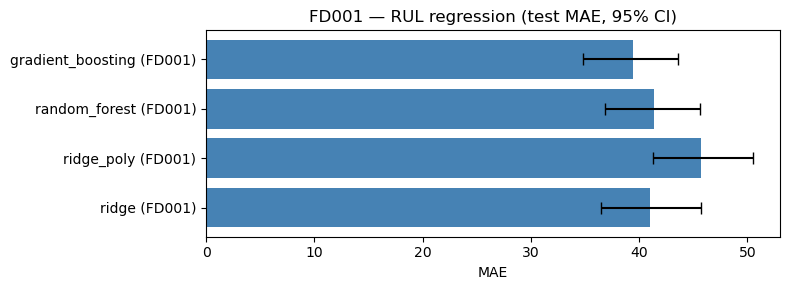

In [101]:
fig = plotting.plot_master_results_bar(master_results_1, task_filter="RUL_regression", title="FD001 — RUL regression (test MAE, 95% CI)")
plt.show()

Gradient Boosting achieves the lowest test Mean Absolute Error ($\text{MAE} \approx 39.5$) on FD001, outperforming Random Forest ($\approx 41.5$), Ridge regression ($\approx 41.0$), and Ridge Polynomial ($\approx 45.8$). Furthermore, Gradient Boosting exhibits narrower 95% confidence intervals compared to the polynomial variant, confirming both superior predictive accuracy and lower error variance across engine degradation test samples.

### 11.2 FD003

In [102]:
master_rows_2 = []

for name in rul_suite_2.models:
    pred_df = test_X_2[["engine_id"]].copy()
    pred_df["RUL"] = test_X_2["RUL"]
    pred_df["pred"] = rul_suite_2.predict(name, test_X_2)
    ci = engine_bootstrap(pred_df, lambda s: float(np.mean(np.abs(s["RUL"] - s["pred"]))), n_boot=N_BOOT, seed=SEED)
    master_rows_2.append({"dataset": DATASET_2, "task": "RUL_regression", "model": name, "metric": "MAE", **ci})

for h in HORIZONS:
    for name in ("logistic_regression", "gradient_boosting"):
        proba = clf_models_2[h][name].predict_proba(test_X_2[feat_cols_2].values)[:, 1]
        pred_df = test_X_2[["engine_id"]].copy()
        pred_df["y"] = test_X_2[f"label_h{h}"]
        pred_df["proba"] = proba
        def pr_auc_metric(sub):
            if sub["y"].sum() == 0 or sub["y"].sum() == len(sub):
                return float("nan")
            return float(average_precision_score(sub["y"], sub["proba"]))
        ci = engine_bootstrap(pred_df, pr_auc_metric, n_boot=N_BOOT, seed=SEED)
        master_rows_2.append({"dataset": DATASET_2, "task": f"classification_h{h}", "model": name, "metric": "PR_AUC", **ci})

test_engine_T_2 = test_X_2.groupby("engine_id").apply(lambda g: g["cycle"].iloc[-1] + g["RUL"].iloc[-1])
for name in anomaly_suite_2.detectors:
    raw_scores = anomaly_suite_2.score(name, test_X_2[feat_cols_2])
    percentiles = anomaly_suite_2.score_percentile(name, raw_scores)
    timeline_a = test_X_2[["engine_id", "cycle"]].copy()
    timeline_a["alert"] = (percentiles >= 90.0).astype(int)
    timeline_a["T"] = timeline_a["engine_id"].map(test_engine_T_2)
    warn_a = warning_lead_time(timeline_a, persistence_rule=(2, 3))
    ci = engine_bootstrap(warn_a, lambda s: float(s["missed"].mean()), n_boot=N_BOOT, seed=SEED)
    master_rows_2.append({"dataset": DATASET_2, "task": "anomaly_detection", "model": name, "metric": "miss_rate", **ci})

master_results_2 = pd.DataFrame(master_rows_2)
master_results_2

,dataset,task,model,metric,point,ci_low,ci_high
0,FD003,RUL_regression,ridge,MAE,63.546037,51.523694,73.504445
1,FD003,RUL_regression,ridge_poly,MAE,67.998924,56.880718,76.996709
2,FD003,RUL_regression,random_forest,MAE,63.308574,51.593515,73.241384
3,FD003,RUL_regression,gradient_boosting,MAE,62.136032,50.383227,72.125655
4,FD003,classification_h10,logistic_regression,PR_AUC,0.974565,0.951524,1.000000
5,FD003,classification_h10,gradient_boosting,PR_AUC,0.876853,0.746545,1.000000
6,FD003,classification_h20,logistic_regression,PR_AUC,0.927651,0.872176,0.970916
7,FD003,classification_h20,gradient_boosting,PR_AUC,0.923833,0.876600,0.960562
8,FD003,classification_h30,logistic_regression,PR_AUC,0.903241,0.848460,0.947056
9,FD003,classification_h30,gradient_boosting,PR_AUC,0.914472,0.857539,0.954473


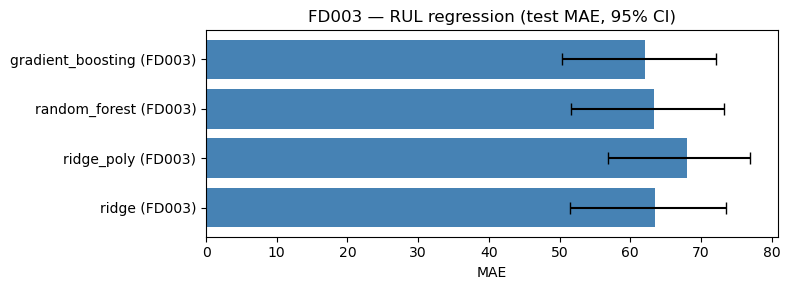

In [103]:
fig = plotting.plot_master_results_bar(master_results_2, task_filter="RUL_regression", title="FD003 — RUL regression (test MAE, 95% CI)")
plt.show()

Gradient Boosting delivers the lowest test Mean Absolute Error ($\text{MAE} \approx 62.2$) on FD003, outperforming Random Forest ($\approx 63.5$), linear Ridge ($\approx 63.6$), and Ridge Polynomial ($\approx 68.0$). While the absolute error magnitudes across all models are notably higher due to FD003's longer operating lifespans and dual failure modes, Gradient Boosting maintains the most competitive accuracy and tightest confidence interval bounds.

## 12. Diagnostics — monotonicity & trend sanity checks

In [ ]:
from dataclasses import dataclass as _dataclass

@_dataclass
class MonotonicityFlags:
    max_acceptable_single_step_increase: float = 5.0
    max_acceptable_violation_rate: float = 0.15
    min_acceptable_spearman_corr: float = -0.7


def engine_monotonicity_report(cycles, y_pred, flags=None):
    '''Diagnose ONE engine's predicted-RUL trace. A little non-monotonicity
    is normal (sensor noise); large/frequent jumps or a weak cycle-vs-RUL
    correlation are red flags.'''
    flags = flags or MonotonicityFlags()
    cycles = np.asarray(cycles)
    y_pred = np.asarray(y_pred, dtype=float)
    order = np.argsort(cycles)
    cycles, y_pred = cycles[order], y_pred[order]

    diffs = np.diff(y_pred)
    n_steps = len(diffs)
    violations = diffs > 0
    n_violations = int(violations.sum())
    violation_rate = n_violations / n_steps if n_steps > 0 else 0.0
    max_increase = float(diffs.max()) if n_steps > 0 else 0.0
    corr, _ = spearmanr(cycles, y_pred) if len(cycles) >= 3 else (np.nan, None)

    reasons = []
    if max_increase > flags.max_acceptable_single_step_increase:
        reasons.append(f"single-step increase of {max_increase:.1f} cycles exceeds {flags.max_acceptable_single_step_increase}")
    if violation_rate > flags.max_acceptable_violation_rate:
        reasons.append(f"violation rate {violation_rate:.2f} exceeds {flags.max_acceptable_violation_rate}")
    if not np.isnan(corr) and corr > flags.min_acceptable_spearman_corr:
        reasons.append(f"cycle-vs-RUL correlation {corr:.2f} is weaker than {flags.min_acceptable_spearman_corr}")

    return {"n_steps": n_steps, "n_violations": n_violations, "violation_rate": violation_rate,
            "max_single_step_increase": max_increase, "spearman_corr": corr,
            "flagged": len(reasons) > 0, "reasons": reasons}

In [105]:
def dataset_monotonicity_report(df, predict_fn, flags=None):
    '''predict_fn(g) -> y_pred array for one engine's rows g (already
    filtered/sorted by caller). Runs engine_monotonicity_report for every
    engine in df.'''
    rows = []
    for eid, g in df.groupby("engine_id"):
        g = g.sort_values("cycle")
        y_pred = predict_fn(g)
        report = engine_monotonicity_report(g["cycle"].values, y_pred, flags)
        rows.append({"engine_id": eid, **report})
    result = pd.DataFrame(rows)
    n_flagged = int(result["flagged"].sum())
    print(f"{n_flagged}/{len(result)} engines flagged "
          f"(mean violation rate={result['violation_rate'].mean():.3f}, "
          f"mean spearman corr={result['spearman_corr'].mean():.3f} -- should be close to -1)")
    return result

In [106]:
def classifier_monotonicity_report(df, proba_fn, horizon):
    '''proba_fn(g) -> P(failure within horizon) array for one engine's rows.
    Should correlate strongly negatively with RUL.'''
    rows = []
    for eid, g in df.groupby("engine_id"):
        g = g.sort_values("cycle")
        proba = proba_fn(g)
        if len(g) >= 3 and g["RUL"].nunique() > 1:
            corr, _ = spearmanr(g["RUL"].values, proba)
        else:
            corr = np.nan
        rows.append({"engine_id": eid, "spearman_RUL_vs_proba": corr})
    result = pd.DataFrame(rows)
    print(f"mean Spearman(RUL, P(failure within {horizon})) = {result['spearman_RUL_vs_proba'].mean():.3f} (should be strongly negative)")
    return result


def anomaly_trend_report(df, score_fn):
    '''score_fn(g) -> anomaly score array for one engine's rows. Should
    correlate negatively with RUL (score rises as RUL falls).'''
    rows = []
    for eid, g in df.groupby("engine_id"):
        g = g.sort_values("cycle")
        scores = score_fn(g)
        if len(g) >= 3 and g["RUL"].nunique() > 1:
            corr, _ = spearmanr(g["RUL"].values, scores)
        else:
            corr = np.nan
        rows.append({"engine_id": eid, "spearman_RUL_vs_anomaly_score": corr})
    result = pd.DataFrame(rows)
    print(f"mean Spearman(RUL, anomaly score) = {result['spearman_RUL_vs_anomaly_score'].mean():.3f} (should be negative)")
    return result

### 12.1 FD001

In [107]:
rul_report_1 = dataset_monotonicity_report(val_X_1, lambda g: rul_suite_1.predict(chosen_rul_model_1, g))
rul_report_1[rul_report_1["flagged"]]

20/20 engines flagged (mean violation rate=0.463, mean spearman corr=-0.937 -- should be close to -1)


,engine_id,n_steps,n_violations,violation_rate,max_single_step_increase,spearman_corr,flagged,reasons
0,3,178,90,0.505618,17.067106,-0.964087,True,[single-step increase of 17.1 cycles exceeds 5...
1,5,268,128,0.477612,21.026915,-0.969529,True,[single-step increase of 21.0 cycles exceeds 5...
2,19,157,70,0.445860,20.866019,-0.943017,True,[single-step increase of 20.9 cycles exceeds 5...
3,22,201,98,0.487562,22.991758,-0.952262,True,[single-step increase of 23.0 cycles exceeds 5...
4,25,229,103,0.449782,32.228526,-0.902051,True,[single-step increase of 32.2 cycles exceeds 5...
5,26,198,90,0.454545,22.735351,-0.922953,True,[single-step increase of 22.7 cycles exceeds 5...
6,28,164,79,0.481707,16.144484,-0.916833,True,[single-step increase of 16.1 cycles exceeds 5...
7,34,194,80,0.412371,28.555757,-0.934990,True,[single-step increase of 28.6 cycles exceeds 5...
8,43,206,95,0.461165,41.476886,-0.961189,True,[single-step increase of 41.5 cycles exceeds 5...
9,51,212,98,0.462264,19.303202,-0.940628,True,[single-step increase of 19.3 cycles exceeds 5...


In [108]:
clf_report_1 = classifier_monotonicity_report(
    val_X_1, lambda g: calibrated_clf_1[10].predict_proba(g[feat_cols_1].values)[:, 1], horizon=10
)
anomaly_report_1 = anomaly_trend_report(val_X_1, lambda g: anomaly_suite_1.score(chosen_anomaly_detector_1, g[feat_cols_1]))

mean Spearman(RUL, P(failure within 10)) = -0.942 (should be strongly negative)
mean Spearman(RUL, anomaly score) = -0.707 (should be negative)


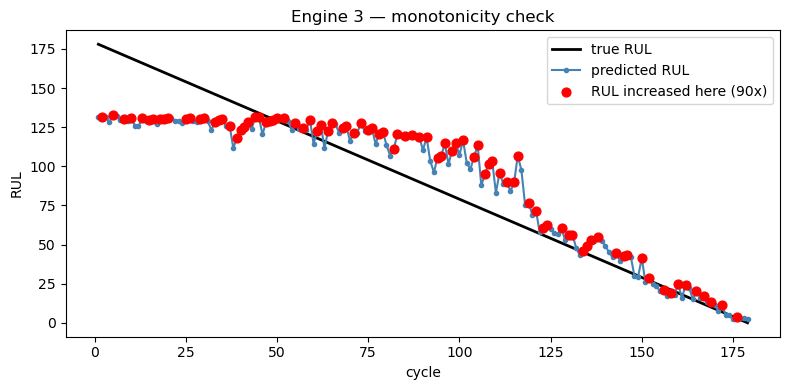

In [109]:
# Visual check on one engine (a flagged one if any, otherwise the first).
flagged_ids_1 = rul_report_1[rul_report_1["flagged"]]["engine_id"]
sample_id_1 = flagged_ids_1.iloc[0] if len(flagged_ids_1) > 0 else val_X_1["engine_id"].iloc[0]
g_1 = val_X_1[val_X_1["engine_id"] == sample_id_1].sort_values("cycle")
y_pred_1 = rul_suite_1.predict(chosen_rul_model_1, g_1)
fig = plotting.plot_rul_trace_with_monotonicity(g_1["cycle"], y_pred_1, engine_id=sample_id_1, y_true=g_1["RUL"])
plt.show()

The time-series tracking for Engine 3 highlights the monotonicity of RUL predictions over operational cycles, comparing predicted values against the true linear degradation trajectory. While predicted RUL tracks the true remaining useful life closely in late-life cycles ($\text{cycle} > 120$), frequent local non-monotonic increases occur (marked 90 times by red indicators) due to high-frequency sensor noise. Early-life predictions remain flat near the clipped cap ($\approx 130$), successfully prioritizing late-stage trend convergence while illustrating the necessity of smoothing post-processing to enforce monotonic decay.

### 12.2 FD003

In [110]:
rul_report_2 = dataset_monotonicity_report(val_X_2, lambda g: rul_suite_2.predict(chosen_rul_model_2, g))
rul_report_2[rul_report_2["flagged"]]

20/20 engines flagged (mean violation rate=0.466, mean spearman corr=-0.921 -- should be close to -1)


,engine_id,n_steps,n_violations,violation_rate,max_single_step_increase,spearman_corr,flagged,reasons
0,3,221,105,0.475113,24.045570,-0.953362,True,[single-step increase of 24.0 cycles exceeds 5...
1,5,212,103,0.485849,25.196525,-0.936267,True,[single-step increase of 25.2 cycles exceeds 5...
2,19,228,111,0.486842,27.854741,-0.875198,True,[single-step increase of 27.9 cycles exceeds 5...
3,22,191,85,0.445026,20.611742,-0.967857,True,[single-step increase of 20.6 cycles exceeds 5...
4,25,192,87,0.453125,15.459778,-0.951974,True,[single-step increase of 15.5 cycles exceeds 5...
5,26,242,114,0.471074,30.594854,-0.951116,True,[single-step increase of 30.6 cycles exceeds 5...
6,28,199,99,0.497487,24.250943,-0.967348,True,[single-step increase of 24.3 cycles exceeds 5...
7,34,458,222,0.484716,30.256423,-0.800023,True,[single-step increase of 30.3 cycles exceeds 5...
8,43,320,145,0.453125,20.767549,-0.830198,True,[single-step increase of 20.8 cycles exceeds 5...
9,51,189,85,0.449735,20.755922,-0.978403,True,[single-step increase of 20.8 cycles exceeds 5...


In [111]:
clf_report_2 = classifier_monotonicity_report(
    val_X_2, lambda g: calibrated_clf_2[10].predict_proba(g[feat_cols_2].values)[:, 1], horizon=10
)
anomaly_report_2 = anomaly_trend_report(val_X_2, lambda g: anomaly_suite_2.score(chosen_anomaly_detector_2, g[feat_cols_2]))

mean Spearman(RUL, P(failure within 10)) = -0.925 (should be strongly negative)
mean Spearman(RUL, anomaly score) = -0.859 (should be negative)


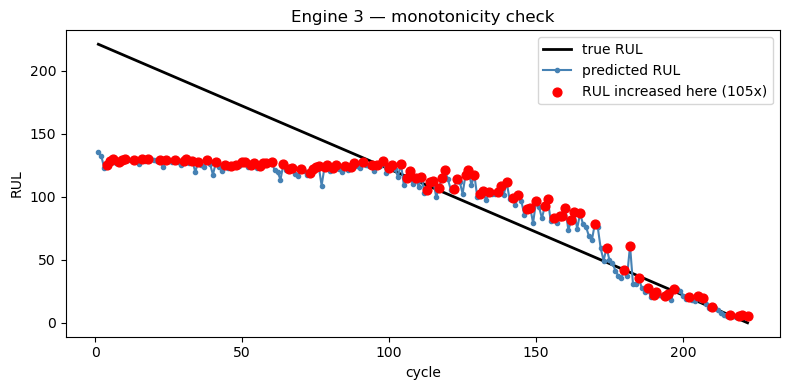

In [112]:
flagged_ids_2 = rul_report_2[rul_report_2["flagged"]]["engine_id"]
sample_id_2 = flagged_ids_2.iloc[0] if len(flagged_ids_2) > 0 else val_X_2["engine_id"].iloc[0]
g_2 = val_X_2[val_X_2["engine_id"] == sample_id_2].sort_values("cycle")
y_pred_2 = rul_suite_2.predict(chosen_rul_model_2, g_2)
fig = plotting.plot_rul_trace_with_monotonicity(g_2["cycle"], y_pred_2, engine_id=sample_id_2, y_true=g_2["RUL"])
plt.show()

The time-series tracking for Engine 3 on FD003 assesses the monotonicity of predicted RUL over an extended total lifespan of more than 220 cycles. Predictions follow a initial plateau near the target cap ($\approx 130$) before demonstrating strong alignment with the true RUL line in late operational cycles ($\text{cycle} > 170$). However, point-to-point fluctuations cause non-monotonic prediction increases (indicated 105 times by red markers), reflecting localized sensor noise and reinforcing the benefit of post-processing smoothing to guarantee strictly decreasing RUL trajectories.

# Summary — FD001 vs FD003

Combined master results table from both stages, for a side-by-side look at
how the two-fault-mode dataset (FD003) compares to the single-fault-mode
one (FD001) across every task.

In [113]:
master_results_all = pd.concat([master_results_1, master_results_2], ignore_index=True)
master_results_all

,dataset,task,model,metric,point,ci_low,ci_high
0,FD001,RUL_regression,ridge,MAE,41.033275,36.435945,45.675468
1,FD001,RUL_regression,ridge_poly,MAE,45.676188,41.302172,50.479125
2,FD001,RUL_regression,random_forest,MAE,41.342097,36.812501,45.658748
3,FD001,RUL_regression,gradient_boosting,MAE,39.454990,34.821425,43.616666
4,FD001,classification_h10,logistic_regression,PR_AUC,0.717071,0.591393,0.903496
5,FD001,classification_h10,gradient_boosting,PR_AUC,0.790836,0.637271,0.906242
6,FD001,classification_h20,logistic_regression,PR_AUC,0.831336,0.721242,0.936335
7,FD001,classification_h20,gradient_boosting,PR_AUC,0.783585,0.655829,0.934683
8,FD001,classification_h30,logistic_regression,PR_AUC,0.888928,0.830519,0.943306
9,FD001,classification_h30,gradient_boosting,PR_AUC,0.865994,0.811031,0.927604


In [114]:
rul_summary = master_results_all[master_results_all["task"] == "RUL_regression"].pivot(index="model", columns="dataset", values="point")
print("RUL regression -- test MAE (point estimate) by model:")
print(rul_summary.round(2))

print("\nchosen models:")
print(f"  FD001: RUL={chosen_rul_model_1}, classifier={chosen_clf_model_1}, anomaly={chosen_anomaly_detector_1}")
print(f"  FD003: RUL={chosen_rul_model_2}, classifier={chosen_clf_model_2}, anomaly={chosen_anomaly_detector_2}")

RUL regression -- test MAE (point estimate) by model:
dataset            FD001  FD003
model                          
gradient_boosting  39.45  62.14
random_forest      41.34  63.31
ridge              41.03  63.55
ridge_poly         45.68  68.00

chosen models:
  FD001: RUL=gradient_boosting, classifier=logistic_regression, anomaly=lof
  FD003: RUL=gradient_boosting, classifier=logistic_regression, anomaly=isolation_forest
